# RUN THIS NOTEBOOK: GRU Cued Change Detection + Supervised Training + Cue-Specific Topological Analyses

This version specifically fixes the previous failure mode: **too many early responses / false alarms**.

**Important:** Restart the kernel and run this notebook from top to bottom. Do not reuse variables or outputs from older notebooks.

The configuration should print and pass these checks:

```text
wait_loss_weight = 2.50
respond_loss_weight = 2.25
prechange_response_target = 0.18
prechange_response_penalty_weight = 5.0
change amplitude = 0.14 to 0.18
noise_std = 0.048
response_window = 12
threshold grid = 0.50 to 0.90
threshold score = accuracy - 2*false_alarm_rate - 0.5*lapse_rate
training cue validity = 0.72
neutral training fraction = 0.12
```

This notebook saves all outputs automatically to a timestamped folder beginning with:

```text
RUN_THIS_gru_false_alarm_fixed_results_<timestamp>/
```

and creates a downloadable ZIP file at the end.

It includes:

1. revised environment where cue should be useful but not sufficient;
2. transient cue and trained neutral cue condition;
3. moderate wait/respond loss weights;
4. explicit pre-change response penalty;
5. response-threshold calibration over thresholds up to 0.90;
6. stricter threshold objective penalizing false alarms strongly;
7. matched cue controls: true, neutral, flipped, shuffled;
8. behavior metrics across seeds;
9. cue decoding from pre-change hidden states;
10. hidden-state point-cloud topology;
11. Rouse-like hidden-unit correlation topology;
12. null controls and automatic reports.


In [1]:
# Optional dependency installer.
# This cell is safe to run in Jupyter. It installs only missing packages.
import sys, subprocess, importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "ripser": "ripser",
    "persim": "persim",
}

for module_name, package_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Dependencies ready.")

Dependencies ready.


In [2]:
import os, math, json, shutil, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from datetime import datetime
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from ripser import ripser
from persim import plot_diagrams

warnings.filterwarnings("ignore")

# Small GRU workloads can become unexpectedly slow with too many CPU threads.
try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Set QUICK_RUN=True to debug the notebook quickly.
# Set QUICK_RUN=False for final results.
QUICK_RUN = False
RUN_TOPOLOGY = True

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = Path(f"RUN_THIS_gru_cue_specific_topology_results_{RUN_ID}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(exist_ok=True)
(RESULTS_DIR / "models").mkdir(exist_ok=True)
(RESULTS_DIR / "csv").mkdir(exist_ok=True)
(RESULTS_DIR / "topology").mkdir(exist_ok=True)

print("All outputs will be saved to:", RESULTS_DIR.resolve())

Device: cpu
All outputs will be saved to: /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232


## 1. Constants and configuration

Actions:

```text
0 = wait
1 = choose left
2 = choose right
```

Cue channels:

```text
left cue    = [1, 0, 0]
right cue   = [0, 1, 0]
neutral cue = [0, 0, 1]
```

The cue is **transient**. It appears only during the first few timesteps, then all cue channels become zero. Therefore, the GRU has to store the cue in its recurrent hidden state.

In [3]:
# Sides and actions
SIDE_LEFT = 0
SIDE_RIGHT = 1

ACTION_WAIT = 0
ACTION_LEFT = 1
ACTION_RIGHT = 2

ACTION_NAMES = {
    ACTION_WAIT: "wait",
    ACTION_LEFT: "choose_left",
    ACTION_RIGHT: "choose_right",
}

# Cue types
CUE_LEFT = 0
CUE_RIGHT = 1
CUE_NEUTRAL = 2

CUE_NAMES = {
    CUE_LEFT: "left",
    CUE_RIGHT: "right",
    CUE_NEUTRAL: "neutral",
}

@dataclass
class EnvConfig:
    # Sequence/task timing.
    # The response window is long enough that the model can respond reliably,
    # but not so long that waiting forever is acceptable.
    seq_len: int = 36
    cue_duration: int = 2
    min_pre_change: int = 6
    response_window: int = 12
    post_window: int = 2

    # Stimulus generation: tuned to be learnable but still uncertain.
    # Compared with the previous version, the change is easier and the noise is lower.
    baseline_low: float = 0.40
    baseline_high: float = 0.60
    change_amp_low: float = 0.14
    change_amp_high: float = 0.18
    noise_std: float = 0.048
    clip_stimuli: bool = True

    # Distractor bumps before the true change: still present, but not overwhelming.
    distractor_prob: float = 0.07
    distractor_amp_low: float = 0.035
    distractor_amp_high: float = 0.060

    # Cue validity.
    # Training validity is deliberately below 0.8 so invalid trials are common enough
    # to prevent the network from learning a blind cue-following shortcut.
    train_cue_validity: float = 0.72
    eval_cue_validity: float = 0.80

    # Neutral cue is included during training so neutral evaluation is not out-of-distribution,
    # but kept relatively rare so the model still benefits from learning informative cues.
    train_neutral_fraction: float = 0.12

    # Observation: 3 cue channels + left stim + right stim + broad phase signal.
    # The cue is transient: it is visible only during cue_duration.
    input_size: int = 6

@dataclass
class TrainConfig:
    hidden_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-5
    epochs: int = 220
    batches_per_epoch: int = 25
    batch_size: int = 256

    # Main response-loss fix:
    # wait is no longer weighted at 5.0 because that produced very high lapse rates.
    # respond is upweighted because respond timesteps are rarer than wait timesteps.
    wait_loss_weight: float = 2.50
    respond_loss_weight: float = 2.25

    # Explicit pre-change response penalty.
    # This discourages the response head from exceeding a low response probability before the real change.
    prechange_response_target: float = 0.18
    prechange_response_penalty_weight: float = 5.0

    # Side-choice loss.
    side_loss_weight: float = 1.0
    invalid_side_weight: float = 2.0
    neutral_side_weight: float = 1.1

    # Response threshold calibration.
    # The final threshold is selected on validation trials for each seed.
    response_threshold_grid: tuple = (0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90)
    threshold_val_trials: int = 1600

    # Evaluation
    response_threshold: float = 0.70  # fallback if calibration is disabled
    eval_trials: int = 2500
    eval_batch_size: int = 512

@dataclass
class TDAConfig:
    n_tda_trials: int = 1200
    max_hidden_points: int = 650
    pca_dims_for_hidden_tda: int = 15
    hidden_maxdim: int = 1
    unit_maxdim: int = 2
    n_betti_grid: int = 200

# Quick-run overrides
if QUICK_RUN:
    TRAIN_CFG = TrainConfig(
        epochs=10,
        batches_per_epoch=3,
        batch_size=128,
        eval_trials=500,
        threshold_val_trials=400,
    )
    TDA_CFG = TDAConfig(n_tda_trials=250, max_hidden_points=250)
    SEEDS = [0]
else:
    TRAIN_CFG = TrainConfig()
    TDA_CFG = TDAConfig()
    SEEDS = [0, 1, 2, 3, 4]

ENV_CFG = EnvConfig()

with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump({"env": asdict(ENV_CFG), "train": asdict(TRAIN_CFG), "tda": asdict(TDA_CFG), "seeds": SEEDS}, f, indent=2)

ENV_CFG, TRAIN_CFG, TDA_CFG, SEEDS

(EnvConfig(seq_len=36, cue_duration=2, min_pre_change=6, response_window=12, post_window=2, baseline_low=0.4, baseline_high=0.6, change_amp_low=0.14, change_amp_high=0.18, noise_std=0.048, clip_stimuli=True, distractor_prob=0.07, distractor_amp_low=0.035, distractor_amp_high=0.06, train_cue_validity=0.72, eval_cue_validity=0.8, train_neutral_fraction=0.12, input_size=6),
 TrainConfig(hidden_size=64, lr=0.001, weight_decay=1e-05, epochs=220, batches_per_epoch=25, batch_size=256, wait_loss_weight=2.5, respond_loss_weight=2.25, prechange_response_target=0.18, prechange_response_penalty_weight=5.0, side_loss_weight=1.0, invalid_side_weight=2.0, neutral_side_weight=1.1, response_threshold_grid=(0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9), threshold_val_trials=1600, response_threshold=0.7, eval_trials=2500, eval_batch_size=512),
 TDAConfig(n_tda_trials=1200, max_hidden_points=650, pca_dims_for_hidden_tda=15, hidden_maxdim=1, unit_maxdim=2, n_betti_grid=200),
 [0, 1, 2, 3, 4])

In [ ]:
# Hard configuration check: this cell must pass.
# If it fails, you are not running the corrected notebook/configuration.
assert ENV_CFG.response_window == 12, ENV_CFG.response_window
assert abs(ENV_CFG.change_amp_low - 0.14) < 1e-9, ENV_CFG.change_amp_low
assert abs(ENV_CFG.change_amp_high - 0.18) < 1e-9, ENV_CFG.change_amp_high
assert abs(ENV_CFG.noise_std - 0.048) < 1e-9, ENV_CFG.noise_std
assert abs(ENV_CFG.train_cue_validity - 0.72) < 1e-9, ENV_CFG.train_cue_validity
assert abs(ENV_CFG.train_neutral_fraction - 0.12) < 1e-9, ENV_CFG.train_neutral_fraction
assert abs(TRAIN_CFG.wait_loss_weight - 2.50) < 1e-9, TRAIN_CFG.wait_loss_weight
assert abs(TRAIN_CFG.respond_loss_weight - 2.25) < 1e-9, TRAIN_CFG.respond_loss_weight
assert abs(TRAIN_CFG.prechange_response_target - 0.18) < 1e-9, TRAIN_CFG.prechange_response_target
assert abs(TRAIN_CFG.prechange_response_penalty_weight - 5.0) < 1e-9, TRAIN_CFG.prechange_response_penalty_weight
assert TRAIN_CFG.response_threshold_grid[0] == 0.50 and TRAIN_CFG.response_threshold_grid[-1] == 0.90, TRAIN_CFG.response_threshold_grid
print("CONFIG CHECK PASSED")
print("wait_loss_weight:", TRAIN_CFG.wait_loss_weight)
print("respond_loss_weight:", TRAIN_CFG.respond_loss_weight)
print("prechange_response_target:", TRAIN_CFG.prechange_response_target)
print("prechange_response_penalty_weight:", TRAIN_CFG.prechange_response_penalty_weight)
print("change amplitude:", ENV_CFG.change_amp_low, "to", ENV_CFG.change_amp_high)
print("noise_std:", ENV_CFG.noise_std)
print("response_window:", ENV_CFG.response_window)
print("threshold grid:", TRAIN_CFG.response_threshold_grid)
print("results folder:", RESULTS_DIR.resolve())

## What changed in this corrected version

The previous run selected thresholds that were too low, so the model responded before the actual change on many trials. This notebook specifically fixes that by:

1. sweeping response thresholds from **0.50 to 0.90**;
2. selecting thresholds with a strict false-alarm penalty:
   
   \[
   score = accuracy - 2\cdot false\_alarm\_rate - 0.5\cdot lapse\_rate
   \]

3. adding an explicit pre-change penalty if \(P(respond)\) exceeds **0.18** before the true change;
4. using moderate response-loss weights instead of pushing too hard toward respond or wait;
5. keeping the stimulus evidence learnable with change amplitude **0.14–0.18**, noise **0.048**, and response window **12**.


## Added in this version

This notebook keeps the same training and evaluation configuration as the last good behavioral run, then adds two cue-specific topology analyses:

1. **Cue-induced hidden-state difference topology**: persistent homology on matched hidden-state differences, especially
   
   \[
   \Delta h = h_{\text{true cue}} - h_{\text{neutral cue}}
   \]

2. **Unit-specific Rouse-like analysis**: identify whether each GRU hidden unit is more sensitive to the left or right stream, then compare hidden-unit correlation topology when attention is directed toward the unit group's preferred stream versus away from it.


## 2. Environment

The environment generates two noisy visual streams:

\[
s_L(t)=\mu_L(t)+\epsilon_L(t), \qquad s_R(t)=\mu_R(t)+\epsilon_R(t)
\]

Before the change, both streams fluctuate around a random baseline. At the change time, one stream shifts by a moderate amount for a limited response window.

The agent receives only the current observation:

\[
o_t=[c_L(t), c_R(t), c_N(t), s_L(t), s_R(t), p_t]
\]

where \(p_t\) is a broad phase signal: it tells the network that the cue period is over, but it does **not** reveal the exact change time.

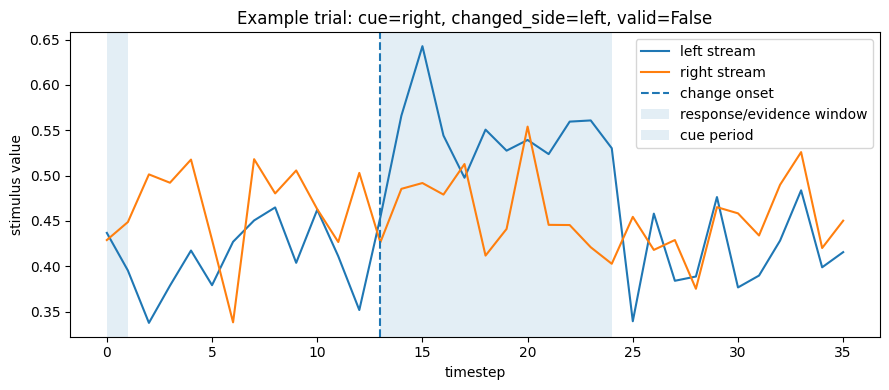

In [4]:
class CuedChangeDetectionEnv:
    def __init__(self, cfg: EnvConfig, seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)

    def _opposite_side(self, side):
        return SIDE_RIGHT if side == SIDE_LEFT else SIDE_LEFT

    def _choose_informative_cue(self, changed_side, cue_validity):
        if self.rng.random() < cue_validity:
            return changed_side
        return self._opposite_side(changed_side)

    def generate_trials(self, n_trials, split="train", exact_validity=None):
        """
        Generate latent trial variables and stimulus streams.
        Does not yet apply cue-control modes.
        """
        cfg = self.cfg
        T = cfg.seq_len

        changed_side = self.rng.integers(0, 2, size=n_trials)  # 0 left, 1 right
        baselines = self.rng.uniform(cfg.baseline_low, cfg.baseline_high, size=(n_trials, 2))
        amplitudes = self.rng.uniform(cfg.change_amp_low, cfg.change_amp_high, size=n_trials)
        signs = self.rng.choice([-1.0, 1.0], size=n_trials)

        latest_change_time = cfg.seq_len - cfg.response_window - cfg.post_window
        earliest_change_time = cfg.cue_duration + cfg.min_pre_change
        if latest_change_time <= earliest_change_time:
            raise ValueError("Timing configuration leaves no room for change times.")
        change_time = self.rng.integers(earliest_change_time, latest_change_time + 1, size=n_trials)

        # Determine true informative cue side.
        if split == "train":
            cue_validity = cfg.train_cue_validity
            neutral_fraction = cfg.train_neutral_fraction
        else:
            cue_validity = cfg.eval_cue_validity if exact_validity is None else exact_validity
            neutral_fraction = 0.0

        cue_type = np.empty(n_trials, dtype=np.int64)
        true_cue_side = np.empty(n_trials, dtype=np.int64)
        valid = np.empty(n_trials, dtype=bool)

        for i in range(n_trials):
            informative_cue = self._choose_informative_cue(changed_side[i], cue_validity)
            true_cue_side[i] = informative_cue
            valid[i] = informative_cue == changed_side[i]

            if split == "train" and self.rng.random() < neutral_fraction:
                cue_type[i] = CUE_NEUTRAL
            else:
                cue_type[i] = CUE_LEFT if informative_cue == SIDE_LEFT else CUE_RIGHT

        stimuli = np.zeros((n_trials, T, 2), dtype=np.float32)

        for i in range(n_trials):
            means = np.repeat(baselines[i][None, :], T, axis=0)
            ctime = change_time[i]
            rend = min(T, ctime + cfg.response_window)
            side = changed_side[i]
            means[ctime:rend, side] = means[ctime:rend, side] + signs[i] * amplitudes[i]

            # Add occasional brief pre-change distractor bump to make one-sample thresholding risky.
            if self.rng.random() < cfg.distractor_prob:
                max_pre = max(cfg.cue_duration + 1, ctime - 1)
                if max_pre > cfg.cue_duration:
                    dt = self.rng.integers(cfg.cue_duration, max_pre)
                    dside = self.rng.integers(0, 2)
                    damp = self.rng.uniform(cfg.distractor_amp_low, cfg.distractor_amp_high)
                    dsign = self.rng.choice([-1.0, 1.0])
                    means[dt, dside] += dsign * damp

            noise = self.rng.normal(0.0, cfg.noise_std, size=(T, 2))
            values = means + noise
            if cfg.clip_stimuli:
                values = np.clip(values, 0.0, 1.0)
            stimuli[i] = values.astype(np.float32)

        return {
            "stimuli": stimuli,
            "changed_side": changed_side.astype(np.int64),
            "change_time": change_time.astype(np.int64),
            "cue_type": cue_type.astype(np.int64),
            "true_cue_side": true_cue_side.astype(np.int64),
            "valid": valid,
            "baselines": baselines.astype(np.float32),
            "amplitudes": amplitudes.astype(np.float32),
            "signs": signs.astype(np.float32),
        }

    def build_observations(self, trials, cue_mode="true"):
        """
        cue_mode:
            true     = use the actual cue type stored in the trials
            neutral  = neutral cue during cue period
            flipped  = swap left and right cues during cue period
            shuffled = shuffle cue types across trials while preserving one-hot cue format
        """
        cfg = self.cfg
        stimuli = trials["stimuli"]
        n, T, _ = stimuli.shape

        cue_type = trials["cue_type"].copy()

        if cue_mode == "true":
            used_cue_type = cue_type.copy()
        elif cue_mode == "neutral":
            used_cue_type = np.full(n, CUE_NEUTRAL, dtype=np.int64)
        elif cue_mode == "flipped":
            used_cue_type = cue_type.copy()
            used_cue_type[cue_type == CUE_LEFT] = CUE_RIGHT
            used_cue_type[cue_type == CUE_RIGHT] = CUE_LEFT
            used_cue_type[cue_type == CUE_NEUTRAL] = CUE_NEUTRAL
        elif cue_mode == "shuffled":
            perm = self.rng.permutation(n)
            used_cue_type = cue_type[perm].copy()
        else:
            raise ValueError(f"Unknown cue_mode: {cue_mode}")

        cue_channels = np.zeros((n, T, 3), dtype=np.float32)
        for i, ct in enumerate(used_cue_type):
            cue_channels[i, :cfg.cue_duration, ct] = 1.0

        # Broad phase signal: cue period vs post-cue period. Does not reveal change time.
        phase = np.zeros((n, T, 1), dtype=np.float32)
        phase[:, cfg.cue_duration:, 0] = 1.0

        obs = np.concatenate([cue_channels, stimuli, phase], axis=-1).astype(np.float32)
        return obs, used_cue_type

    def build_targets(self, trials):
        cfg = self.cfg
        n, T, _ = trials["stimuli"].shape
        respond = np.zeros((n, T), dtype=np.float32)
        side_target = np.zeros((n, T), dtype=np.int64)
        side_loss_weight = np.ones((n, T), dtype=np.float32)

        for i in range(n):
            ctime = int(trials["change_time"][i])
            rend = min(T, ctime + cfg.response_window)
            respond[i, ctime:rend] = 1.0
            side_target[i, ctime:rend] = int(trials["changed_side"][i])

            # Extra side-choice weight on invalid trials to prevent blind cue-following.
            cue_type = int(trials["cue_type"][i])
            if cue_type == CUE_NEUTRAL:
                weight = TRAIN_CFG.neutral_side_weight
            elif not bool(trials["valid"][i]):
                weight = TRAIN_CFG.invalid_side_weight
            else:
                weight = 1.0
            side_loss_weight[i, ctime:rend] = weight

        return respond, side_target, side_loss_weight

    def sample_batch(self, n_trials, split="train", cue_mode="true"):
        trials = self.generate_trials(n_trials, split=split)
        obs, used_cue_type = self.build_observations(trials, cue_mode=cue_mode)
        respond, side_target, side_loss_weight = self.build_targets(trials)
        trials["used_cue_type"] = used_cue_type
        return obs, respond, side_target, side_loss_weight, trials

# Quick visual check of one generated trial.
def plot_example_trial(env, save_path=None):
    trials = env.generate_trials(1, split="eval")
    obs, used_cue = env.build_observations(trials, cue_mode="true")
    t = np.arange(env.cfg.seq_len)
    ctime = int(trials["change_time"][0])
    rend = min(env.cfg.seq_len, ctime + env.cfg.response_window)

    plt.figure(figsize=(9, 4))
    plt.plot(t, trials["stimuli"][0, :, 0], label="left stream")
    plt.plot(t, trials["stimuli"][0, :, 1], label="right stream")
    plt.axvline(ctime, linestyle="--", label="change onset")
    plt.axvspan(ctime, rend-1, alpha=0.12, label="response/evidence window")
    plt.axvspan(0, env.cfg.cue_duration-1, alpha=0.12, label="cue period")
    plt.xlabel("timestep")
    plt.ylabel("stimulus value")
    plt.title(f"Example trial: cue={CUE_NAMES[int(used_cue[0])]}, changed_side={'left' if trials['changed_side'][0]==0 else 'right'}, valid={bool(trials['valid'][0])}")
    plt.legend(loc="best")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200)
    plt.show()

env_preview = CuedChangeDetectionEnv(ENV_CFG, seed=123)
plot_example_trial(env_preview, RESULTS_DIR / "figures" / "example_trial_visual_stream.png")

## 3. Two-head GRU model

Instead of directly predicting one of three actions at every timestep, the model uses two heads:

1. **Response head**: wait vs respond
2. **Side head**: left vs right, trained only during the post-change response/evidence window

This is intended to reduce false alarms. The model first learns **when** to respond, then learns **which side** changed.

In [6]:
class TwoHeadGRUPolicy(nn.Module):
    def __init__(self, input_size=6, hidden_size=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.respond_head = nn.Linear(hidden_size, 1)
        self.side_head = nn.Linear(hidden_size, 2)

    def forward(self, obs, h0=None):
        # obs: [batch, time, input_size]
        out, h_final = self.gru(obs, h0)
        respond_logits = self.respond_head(out).squeeze(-1)  # [batch, time]
        side_logits = self.side_head(out)                    # [batch, time, 2]
        return respond_logits, side_logits, out, h_final

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_preview = TwoHeadGRUPolicy(input_size=ENV_CFG.input_size, hidden_size=TRAIN_CFG.hidden_size)
print(model_preview)
print("Trainable parameters:", count_parameters(model_preview))

TwoHeadGRUPolicy(
  (gru): GRU(6, 64, batch_first=True)
  (respond_head): Linear(in_features=64, out_features=1, bias=True)
  (side_head): Linear(in_features=64, out_features=2, bias=True)
)
Trainable parameters: 14019


## 4. Training and evaluation functions

The model has two supervised heads:

\[
\mathcal{L}=\mathcal{L}_{respond}+\mathcal{L}_{side}+\mathcal{L}_{prechange\ penalty}
\]

Key changes in this version:

- The threshold grid now extends from **0.50 to 0.90**, because the previous model often had pre-change response probabilities above 0.50.
- Threshold selection uses the stricter objective:

```text
score = accuracy - 2*false_alarm_rate - 0.5*lapse_rate
```

- The loss includes an explicit pre-change response penalty:

\[
\mathcal{L}_{pre}=\lambda\,\mathbb{E}_{t<change}\left[\max(0, p_{respond}(t)-0.18)^2
ight]
\]

- Wait and respond loss weights are balanced more moderately:

```text
wait_loss_weight = 2.50
respond_loss_weight = 2.25
```


In [7]:
def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_losses(model, batch, train_cfg: TrainConfig, device):
    obs_np, respond_np, side_np, side_w_np, trials = batch

    obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
    respond_target = torch.tensor(respond_np, dtype=torch.float32, device=device)
    side_target = torch.tensor(side_np, dtype=torch.long, device=device)
    side_loss_weight = torch.tensor(side_w_np, dtype=torch.float32, device=device)

    respond_logits, side_logits, hidden, _ = model(obs)

    # Response loss: binary wait/respond at every timestep.
    resp_loss_raw = F.binary_cross_entropy_with_logits(respond_logits, respond_target, reduction="none")
    resp_weights = torch.where(
        respond_target > 0.5,
        torch.full_like(respond_target, train_cfg.respond_loss_weight),
        torch.full_like(respond_target, train_cfg.wait_loss_weight),
    )
    response_loss = (resp_loss_raw * resp_weights).mean()

    # Side loss only during target response/evidence window.
    mask = respond_target > 0.5
    if mask.sum() > 0:
        side_loss_raw = F.cross_entropy(side_logits[mask], side_target[mask], reduction="none")
        side_weights = side_loss_weight[mask]
        side_loss = (side_loss_raw * side_weights).sum() / side_weights.sum().clamp_min(1.0)
    else:
        side_loss = torch.tensor(0.0, device=device)

    # Explicit pre-change response penalty.
    # This directly targets the previous failure mode where P(respond) was too high before the actual change.
    p_resp = torch.sigmoid(respond_logits)
    pre_mask = respond_target < 0.5
    if pre_mask.sum() > 0:
        pre_excess = torch.relu(p_resp[pre_mask] - train_cfg.prechange_response_target)
        pre_response_penalty = train_cfg.prechange_response_penalty_weight * (pre_excess ** 2).mean()
    else:
        pre_response_penalty = torch.tensor(0.0, device=device)

    total_loss = response_loss + train_cfg.side_loss_weight * side_loss + pre_response_penalty
    return total_loss, response_loss.detach(), side_loss.detach(), pre_response_penalty.detach()

@torch.no_grad()
def evaluate_on_trials(model, env, trials, cue_mode="true", threshold=0.5, device="cpu"):
    model.eval()
    obs_np, used_cue_type = env.build_observations(trials, cue_mode=cue_mode)
    obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
    respond_logits, side_logits, hidden, _ = model(obs)

    p_resp = torch.sigmoid(respond_logits).cpu().numpy()
    side_pred = torch.argmax(side_logits, dim=-1).cpu().numpy()

    n, T = p_resp.shape
    rows = []

    for i in range(n):
        ctime = int(trials["change_time"][i])
        rend = min(env.cfg.seq_len, ctime + env.cfg.response_window)
        changed = int(trials["changed_side"][i])
        true_cue = int(trials["true_cue_side"][i])
        valid = bool(trials["valid"][i])

        above = np.where(p_resp[i] >= threshold)[0]
        first_t = int(above[0]) if len(above) else None

        false_alarm = False
        lapse = False
        late = False
        correct = False
        choice = None

        if first_t is None:
            lapse = True
        elif first_t < ctime:
            false_alarm = True
            choice = int(side_pred[i, first_t])
        elif ctime <= first_t < rend:
            choice = int(side_pred[i, first_t])
            correct = choice == changed
        else:
            late = True
            choice = int(side_pred[i, first_t])

        rows.append({
            "cue_mode": cue_mode,
            "trial": i,
            "change_time": ctime,
            "response_end": rend,
            "first_response_t": -1 if first_t is None else first_t,
            "response_delay": np.nan if first_t is None else first_t - ctime,
            "changed_side": changed,
            "true_cue_side": true_cue,
            "used_cue_type": int(used_cue_type[i]),
            "valid": valid,
            "choice": -1 if choice is None else choice,
            "correct": correct,
            "false_alarm": false_alarm,
            "lapse": lapse,
            "late": late,
            "max_p_resp_prechange": float(p_resp[i, :ctime].max()) if ctime > 0 else 0.0,
            "max_p_resp_window": float(p_resp[i, ctime:rend].max()) if rend > ctime else 0.0,
        })

    df = pd.DataFrame(rows)

    def mean_bool(x):
        return float(np.mean(x)) if len(x) else np.nan

    acc = mean_bool(df["correct"])
    valid_acc = mean_bool(df.loc[df["valid"], "correct"])
    invalid_acc = mean_bool(df.loc[~df["valid"], "correct"])
    fa = mean_bool(df["false_alarm"])
    lapse = mean_bool(df["lapse"])
    late = mean_bool(df["late"])

    # Signal-detection-like d-prime using correct as hit and false alarm as FA.
    # This is a simplified model metric, not a perfect psychometric d'.
    eps = 1.0 / (2 * max(len(df), 1))
    hit_rate = np.clip(acc, eps, 1 - eps)
    fa_rate = np.clip(fa, eps, 1 - eps)
    dprime = NormalDist().inv_cdf(hit_rate) - NormalDist().inv_cdf(fa_rate)

    summary = {
        "cue_mode": cue_mode,
        "accuracy": acc,
        "valid_accuracy": valid_acc,
        "invalid_accuracy": invalid_acc,
        "false_alarm_rate": fa,
        "lapse_rate": lapse,
        "late_rate": late,
        "dprime": float(dprime),
        "mean_max_p_resp_prechange": float(df["max_p_resp_prechange"].mean()),
        "mean_max_p_resp_window": float(df["max_p_resp_window"].mean()),
        "n_trials": int(len(df)),
    }
    return summary, df, hidden.cpu().numpy()


def threshold_selection_score(summary):
    """
    Stricter score used to select a response threshold on validation data.

    Requested objective:
        score = accuracy - 2*false_alarm_rate - 0.5*lapse_rate

    This strongly discourages the early-response failure mode.
    """
    acc = summary.get("accuracy", 0.0)
    fa = summary.get("false_alarm_rate", 0.0)
    lapse = summary.get("lapse_rate", 0.0)
    return acc - 2.0 * fa - 0.5 * lapse

@torch.no_grad()
def calibrate_response_threshold(model, env, train_cfg: TrainConfig, seed_dir: Path, device="cpu"):
    """
    Select a response threshold for the two-stage model.

    The response head outputs P(respond). A fixed threshold of 0.50 can be too strict.
    This function sweeps thresholds on validation trials and selects the threshold with
    the best score. The selected threshold is then used for final evaluation and topology runs.
    """
    val_trials = env.generate_trials(train_cfg.threshold_val_trials, split="eval", exact_validity=env.cfg.eval_cue_validity)

    rows = []
    for thr in train_cfg.response_threshold_grid:
        summary, _, _ = evaluate_on_trials(
            model, env, val_trials, cue_mode="true", threshold=float(thr), device=device
        )
        summary["threshold"] = float(thr)
        summary["selection_score"] = threshold_selection_score(summary)
        rows.append(summary)

    sweep = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)
    best_row = sweep.loc[sweep["selection_score"].idxmax()]
    best_threshold = float(best_row["threshold"])

    sweep.to_csv(seed_dir / "threshold_sweep.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.plot(sweep["threshold"], sweep["accuracy"], marker="o", label="accuracy")
    plt.plot(sweep["threshold"], sweep["false_alarm_rate"], marker="o", label="false alarm")
    plt.plot(sweep["threshold"], sweep["lapse_rate"], marker="o", label="lapse")
    plt.plot(sweep["threshold"], sweep["selection_score"], marker="o", label="selection score")
    plt.axvline(best_threshold, linestyle="--", linewidth=1, label=f"chosen={best_threshold:.2f}")
    plt.xlabel("response threshold")
    plt.ylabel("metric")
    plt.title("Validation threshold calibration")
    plt.legend()
    plt.tight_layout()
    plt.savefig(seed_dir / "threshold_sweep.png", dpi=200)
    plt.close()

    return best_threshold, sweep


def train_one_seed(seed, env_cfg: EnvConfig, train_cfg: TrainConfig, results_dir: Path):
    set_all_seeds(seed)
    env = CuedChangeDetectionEnv(env_cfg, seed=seed)
    model = TwoHeadGRUPolicy(input_size=env_cfg.input_size, hidden_size=train_cfg.hidden_size).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)

    history = []
    checkpoint_epochs = sorted(set([0, train_cfg.epochs // 4, train_cfg.epochs // 2, 3 * train_cfg.epochs // 4, train_cfg.epochs]))
    checkpoints = {}

    # Save initial model.
    checkpoints[0] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, train_cfg.epochs + 1):
        model.train()
        losses, resp_losses, side_losses, pre_penalty_losses = [], [], [], []
        for _ in range(train_cfg.batches_per_epoch):
            batch = env.sample_batch(train_cfg.batch_size, split="train", cue_mode="true")
            opt.zero_grad(set_to_none=True)
            loss, resp_loss, side_loss, pre_penalty_loss = compute_losses(model, batch, train_cfg, DEVICE)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(float(loss.item()))
            resp_losses.append(float(resp_loss.item()))
            side_losses.append(float(side_loss.item()))
            pre_penalty_losses.append(float(pre_penalty_loss.item()))

        row = {
            "seed": seed,
            "epoch": epoch,
            "loss": np.mean(losses),
            "response_loss": np.mean(resp_losses),
            "side_loss": np.mean(side_losses),
            "pre_response_penalty": np.mean(pre_penalty_losses),
        }
        history.append(row)

        if epoch in checkpoint_epochs:
            checkpoints[epoch] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % max(1, train_cfg.epochs // 10) == 0:
            print(f"seed {seed:02d} epoch {epoch:03d}/{train_cfg.epochs} loss={row['loss']:.4f} resp={row['response_loss']:.4f} side={row['side_loss']:.4f} prepen={row['pre_response_penalty']:.4f}")

    seed_dir = results_dir / f"seed_{seed:02d}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(history).to_csv(seed_dir / "training_history.csv", index=False)
    torch.save(model.state_dict(), seed_dir / "final_model.pt")
    torch.save(checkpoints, seed_dir / "checkpoints.pt")

    return model, env, pd.DataFrame(history), checkpoints

## 5. Hidden-state extraction and cue decoding

Cue decoding is not proof of attention by itself. It only tests whether pre-change hidden states contain cue information.

The stronger behavioral tests are:

```text
true cue > neutral cue
true cue > shuffled/flipped cue
valid > invalid > chance
false alarms are controlled
```

In [8]:
@torch.no_grad()
def collect_prechange_hidden_states(model, env, trials, cue_mode="true", device="cpu"):
    model.eval()
    obs_np, used_cue_type = env.build_observations(trials, cue_mode=cue_mode)
    obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
    respond_logits, side_logits, hidden, _ = model(obs)
    H = hidden.cpu().numpy()

    X = []
    rows = []
    for i in range(H.shape[0]):
        ctime = int(trials["change_time"][i])
        for t in range(env.cfg.cue_duration, ctime):
            X.append(H[i, t])
            rows.append({
                "trial": i,
                "t": t,
                "time_to_change": t - ctime,
                "changed_side": int(trials["changed_side"][i]),
                "true_cue_side": int(trials["true_cue_side"][i]),
                "cue_type": int(trials["cue_type"][i]),
                "used_cue_type": int(used_cue_type[i]),
                "valid": bool(trials["valid"][i]),
                "cue_mode": cue_mode,
            })
    return np.asarray(X, dtype=np.float32), pd.DataFrame(rows)

def cue_decoding_analysis(X, df, seed=0):
    # Decode true cue side from pre-change hidden states.
    # Only use trials whose true cue side is left/right. Neutral training condition does not appear in eval trials.
    y = df["true_cue_side"].to_numpy().astype(int)
    Xz = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(Xz, y, test_size=0.3, random_state=seed, stratify=y)

    clf = LogisticRegression(max_iter=1000, solver="lbfgs")
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)

    rng = np.random.default_rng(seed)
    y_shuf = y.copy()
    rng.shuffle(y_shuf)
    X_train, X_test, y_train, y_test = train_test_split(Xz, y_shuf, test_size=0.3, random_state=seed, stratify=y_shuf)
    clf_null = LogisticRegression(max_iter=1000, solver="lbfgs")
    clf_null.fit(X_train, y_train)
    pred_null = clf_null.predict(X_test)
    acc_null = accuracy_score(y_test, pred_null)

    return {"cue_decoder_accuracy": float(acc), "cue_decoder_shuffled_label_accuracy": float(acc_null)}

## 6. Topological analysis helper functions

Two analyses are implemented:

### Analysis 1: hidden-state point-cloud topology

Each point is one full hidden-state vector \(h_t\in\mathbb{R}^{64}\).

### Analysis 2: Rouse-like hidden-unit correlation topology

Each vertex is one GRU hidden unit. Distances are based on hidden-unit correlations:

\[
D_{ij}=1-r_{ij}
\]

This is the closer analogue to Rouse et al.'s neuron-correlation topology.

In [9]:
def betti_curve(diagram, eps_grid):
    if diagram is None or len(diagram) == 0:
        return np.zeros_like(eps_grid)
    births = diagram[:, 0]
    deaths = diagram[:, 1]
    deaths = np.where(np.isfinite(deaths), deaths, eps_grid[-1])
    return np.array([np.sum((births <= eps) & (eps < deaths)) for eps in eps_grid])

def summarize_diagrams(dgms, n_grid=200):
    max_death = 1.0
    finite_deaths = []
    for dgm in dgms:
        if dgm is not None and len(dgm):
            finite = dgm[np.isfinite(dgm[:, 1])]
            if len(finite):
                finite_deaths.append(finite[:, 1].max())
    if finite_deaths:
        max_death = max(finite_deaths)
    eps_grid = np.linspace(0, max_death, n_grid)

    rows = []
    for dim, dgm in enumerate(dgms):
        if dgm is None or len(dgm) == 0:
            rows.append({"homology_dim": f"H{dim}", "num_features": 0, "longest_persistence": 0.0, "total_persistence": 0.0, "peak_betti": 0})
            continue
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite):
            lifetimes = finite[:, 1] - finite[:, 0]
            lifetimes = lifetimes[lifetimes > 0]
        else:
            lifetimes = np.array([])
        beta = betti_curve(dgm, eps_grid)
        rows.append({
            "homology_dim": f"H{dim}",
            "num_features": int(len(lifetimes)),
            "longest_persistence": float(lifetimes.max()) if len(lifetimes) else 0.0,
            "total_persistence": float(lifetimes.sum()) if len(lifetimes) else 0.0,
            "peak_betti": int(beta.max()) if len(beta) else 0,
        })
    return pd.DataFrame(rows), eps_grid

def plot_betti_curves(dgms, title, save_path, n_grid=200):
    summary, eps_grid = summarize_diagrams(dgms, n_grid=n_grid)
    plt.figure(figsize=(7, 5))
    for dim, dgm in enumerate(dgms):
        plt.plot(eps_grid, betti_curve(dgm, eps_grid), label=f"H{dim}")
    plt.xlabel("distance threshold ε")
    plt.ylabel("Betti number")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()
    return summary

def plot_persistence_diagram(dgms, title, save_path):
    plt.figure(figsize=(6, 5))
    plot_diagrams(dgms, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

def fit_shared_hidden_transform(hidden_by_mode, pca_dims=15):
    pooled = np.vstack(list(hidden_by_mode.values()))
    scaler = StandardScaler().fit(pooled)
    pooled_z = scaler.transform(pooled)
    n_components = min(pca_dims, pooled_z.shape[1], pooled_z.shape[0] - 1)
    pca = PCA(n_components=n_components).fit(pooled_z)
    transformed = {k: pca.transform(scaler.transform(v)) for k, v in hidden_by_mode.items()}
    return scaler, pca, transformed

def hidden_pointcloud_tda(X_transformed, max_points=650, maxdim=1, seed=0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X_transformed, dtype=np.float64)
    if len(X) > max_points:
        idx = rng.choice(len(X), size=max_points, replace=False)
        X = X[idx]
    dgms = ripser(X, maxdim=maxdim)["dgms"]
    summary, _ = summarize_diagrams(dgms)
    return dgms, summary

def make_hidden_nulls(X_transformed, seed=0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X_transformed)
    nulls = {}

    # Matched Gaussian null in transformed coordinates.
    mu = X.mean(axis=0)
    cov = np.cov(X, rowvar=False) + 1e-6 * np.eye(X.shape[1])
    nulls["gaussian_matched_cov"] = rng.multivariate_normal(mu, cov, size=len(X)).astype(np.float32)

    # Feature shuffle: independently permute each feature dimension across samples.
    X_feat = X.copy()
    for j in range(X_feat.shape[1]):
        rng.shuffle(X_feat[:, j])
    nulls["feature_shuffle"] = X_feat.astype(np.float32)

    return nulls

def residualize_by_groups(X, groups):
    X = np.asarray(X, dtype=np.float64)
    groups = np.asarray(groups)
    Xr = X.copy()
    for g in np.unique(groups):
        mask = groups == g
        Xr[mask] = Xr[mask] - Xr[mask].mean(axis=0, keepdims=True)
    return Xr

def rouse_like_unit_tda(X, df=None, residualize=True, seed=0, maxdim=2, distance_type="rouse"):
    X_use = np.asarray(X, dtype=np.float64)
    if residualize and df is not None:
        group_cols = ["time_to_change", "changed_side"]
        group_strings = df[group_cols].astype(str).agg("_".join, axis=1).to_numpy()
        X_use = residualize_by_groups(X_use, group_strings)

    # Standardize each hidden unit across samples.
    Xz = StandardScaler().fit_transform(X_use)
    C = np.corrcoef(Xz, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = np.clip(C, -1.0, 1.0)

    if distance_type == "rouse":
        D = 1.0 - C
    else:
        D = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - C)))
    D = np.maximum(D, 0.0)
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    dgms = ripser(D, maxdim=maxdim, distance_matrix=True)["dgms"]
    summary, _ = summarize_diagrams(dgms)
    return dgms, summary, C, D

def make_unit_nulls(X, seed=0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X)
    nulls = {}

    X_unit = X.copy()
    for j in range(X_unit.shape[1]):
        rng.shuffle(X_unit[:, j])
    nulls["unit_activity_shuffle"] = X_unit.astype(np.float32)

    nulls["independent_gaussian_units"] = rng.normal(0, 1, size=X.shape).astype(np.float32)
    return nulls

## 7. Run training, behavior, cue decoding, and topology across seeds

All outputs are saved automatically into the results folder.

In [10]:
def run_full_seed(seed, env_cfg, train_cfg, tda_cfg, results_dir):
    seed_dir = results_dir / f"seed_{seed:02d}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    model, env, history, checkpoints = train_one_seed(seed, env_cfg, train_cfg, results_dir)
    model.eval()

    # Save training plot
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["loss"], label="total")
    plt.plot(history["epoch"], history["response_loss"], label="response")
    plt.plot(history["epoch"], history["side_loss"], label="side")
    if "pre_response_penalty" in history.columns:
        plt.plot(history["epoch"], history["pre_response_penalty"], label="pre-response penalty")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Training losses, seed {seed}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(seed_dir / "training_losses.png", dpi=200)
    plt.close()

    # Calibrate response threshold on validation trials.
    # This fixes the earlier issue where a fixed threshold produced either too many false alarms
    # or too many lapses depending on the environment difficulty.
    selected_threshold, threshold_sweep = calibrate_response_threshold(
        model, env, train_cfg, seed_dir=seed_dir, device=DEVICE
    )
    print(f"seed {seed:02d} selected response threshold = {selected_threshold:.2f}")

    # Matched evaluation trials.
    eval_trials = env.generate_trials(train_cfg.eval_trials, split="eval", exact_validity=env_cfg.eval_cue_validity)
    cue_modes = ["true", "neutral", "flipped", "shuffled"]

    behavior_rows = []
    trial_dfs = []
    hidden_for_modes = {}
    df_for_modes = {}

    for mode in cue_modes:
        summary, trial_df, _ = evaluate_on_trials(
            model, env, eval_trials, cue_mode=mode,
            threshold=selected_threshold, device=DEVICE
        )
        summary["seed"] = seed
        summary["selected_response_threshold"] = selected_threshold
        behavior_rows.append(summary)
        trial_df["seed"] = seed
        trial_df["selected_response_threshold"] = selected_threshold
        trial_dfs.append(trial_df)

    behavior_df = pd.DataFrame(behavior_rows)
    behavior_trials_df = pd.concat(trial_dfs, ignore_index=True)
    behavior_df.to_csv(seed_dir / "behavior_by_cue_mode.csv", index=False)
    behavior_trials_df.to_csv(seed_dir / "trial_level_behavior.csv", index=False)

    # Pre-change hidden states for cue decoding and topology.
    tda_trials = env.generate_trials(tda_cfg.n_tda_trials, split="eval", exact_validity=env_cfg.eval_cue_validity)
    for mode in cue_modes:
        X, dfh = collect_prechange_hidden_states(model, env, tda_trials, cue_mode=mode, device=DEVICE)
        hidden_for_modes[mode] = X
        df_for_modes[mode] = dfh

    # Cue decoding from true-cue pre-change states.
    cue_dec = cue_decoding_analysis(hidden_for_modes["true"], df_for_modes["true"], seed=seed)
    cue_dec["seed"] = seed
    pd.DataFrame([cue_dec]).to_csv(seed_dir / "cue_decoder.csv", index=False)

    hidden_top_rows = []
    unit_top_rows = []

    if RUN_TOPOLOGY:
        topology_dir = seed_dir / "topology"
        topology_dir.mkdir(exist_ok=True)

        # Shared transform for hidden-state point-cloud TDA across cue modes.
        scaler, pca, hidden_transformed = fit_shared_hidden_transform(
            hidden_for_modes, pca_dims=tda_cfg.pca_dims_for_hidden_tda
        )

        for mode in cue_modes:
            dgms, summary = hidden_pointcloud_tda(
                hidden_transformed[mode],
                max_points=tda_cfg.max_hidden_points,
                maxdim=tda_cfg.hidden_maxdim,
                seed=seed,
            )
            summary["seed"] = seed
            summary["analysis"] = "hidden_state_pointcloud"
            summary["condition"] = mode
            hidden_top_rows.append(summary)
            plot_betti_curves(dgms, f"Hidden-state Betti curves: {mode}, seed {seed}", topology_dir / f"hidden_betti_{mode}.png")
            plot_persistence_diagram(dgms, f"Hidden-state persistence: {mode}, seed {seed}", topology_dir / f"hidden_pd_{mode}.png")

        # Hidden-state nulls based on true-cue transformed point cloud.
        for null_name, X_null in make_hidden_nulls(hidden_transformed["true"], seed=seed).items():
            dgms, summary = hidden_pointcloud_tda(
                X_null,
                max_points=tda_cfg.max_hidden_points,
                maxdim=tda_cfg.hidden_maxdim,
                seed=seed,
            )
            summary["seed"] = seed
            summary["analysis"] = "hidden_state_pointcloud"
            summary["condition"] = null_name
            hidden_top_rows.append(summary)
            plot_betti_curves(dgms, f"Hidden-state null Betti: {null_name}, seed {seed}", topology_dir / f"hidden_betti_{null_name}.png")

        # Rouse-like hidden-unit correlation topology.
        for mode in cue_modes:
            dgms_u, summary_u, C, D = rouse_like_unit_tda(
                hidden_for_modes[mode],
                df=df_for_modes[mode],
                residualize=True,
                seed=seed,
                maxdim=tda_cfg.unit_maxdim,
            )
            summary_u["seed"] = seed
            summary_u["analysis"] = "rouse_like_unit_correlation"
            summary_u["condition"] = mode
            unit_top_rows.append(summary_u)
            plot_betti_curves(dgms_u, f"Rouse-like Betti curves: {mode}, seed {seed}", topology_dir / f"rouse_betti_{mode}.png")
            plot_persistence_diagram(dgms_u, f"Rouse-like persistence: {mode}, seed {seed}", topology_dir / f"rouse_pd_{mode}.png")

            if mode == "true":
                plt.figure(figsize=(6, 5))
                plt.imshow(C, vmin=-1, vmax=1, aspect="auto")
                plt.colorbar(label="hidden-unit correlation")
                plt.title(f"Hidden-unit correlation matrix, seed {seed}")
                plt.xlabel("hidden unit")
                plt.ylabel("hidden unit")
                plt.tight_layout()
                plt.savefig(topology_dir / "hidden_unit_correlation_true.png", dpi=200)
                plt.close()

        for null_name, X_null in make_unit_nulls(hidden_for_modes["true"], seed=seed).items():
            dgms_u, summary_u, C, D = rouse_like_unit_tda(
                X_null,
                df=df_for_modes["true"],
                residualize=False,
                seed=seed,
                maxdim=tda_cfg.unit_maxdim,
            )
            summary_u["seed"] = seed
            summary_u["analysis"] = "rouse_like_unit_correlation"
            summary_u["condition"] = null_name
            unit_top_rows.append(summary_u)
            plot_betti_curves(dgms_u, f"Rouse-like null Betti: {null_name}, seed {seed}", topology_dir / f"rouse_betti_{null_name}.png")

    hidden_top_df = pd.concat(hidden_top_rows, ignore_index=True) if hidden_top_rows else pd.DataFrame()
    unit_top_df = pd.concat(unit_top_rows, ignore_index=True) if unit_top_rows else pd.DataFrame()

    hidden_top_df.to_csv(seed_dir / "hidden_state_topology.csv", index=False)
    unit_top_df.to_csv(seed_dir / "rouse_like_topology.csv", index=False)

    return {
        "seed": seed,
        "history": history,
        "behavior": behavior_df,
        "behavior_trials": behavior_trials_df,
        "cue_decoder": pd.DataFrame([cue_dec]),
        "hidden_topology": hidden_top_df,
        "rouse_like_topology": unit_top_df,
    }

all_results = []
for seed in SEEDS:
    print("\n" + "="*80)
    print(f"Running seed {seed}")
    print("="*80)
    all_results.append(run_full_seed(seed, ENV_CFG, TRAIN_CFG, TDA_CFG, RESULTS_DIR))

print("Finished all seeds.")


Running seed 0
seed 00 epoch 001/220 loss=2.4294 resp=1.5639 side=0.6935 prepen=0.1720
seed 00 epoch 022/220 loss=1.8104 resp=1.0238 side=0.6938 prepen=0.0928
seed 00 epoch 044/220 loss=1.7941 resp=1.0093 side=0.6938 prepen=0.0910
seed 00 epoch 066/220 loss=1.7941 resp=1.0100 side=0.6934 prepen=0.0907
seed 00 epoch 088/220 loss=1.7932 resp=1.0082 side=0.6932 prepen=0.0918
seed 00 epoch 110/220 loss=1.7880 resp=1.0045 side=0.6929 prepen=0.0906
seed 00 epoch 132/220 loss=1.7891 resp=1.0068 side=0.6910 prepen=0.0913
seed 00 epoch 154/220 loss=1.1327 resp=0.7383 side=0.3316 prepen=0.0629
seed 00 epoch 176/220 loss=0.7311 resp=0.4826 side=0.2090 prepen=0.0395
seed 00 epoch 198/220 loss=0.5034 resp=0.3641 side=0.1168 prepen=0.0224
seed 00 epoch 220/220 loss=0.4188 resp=0.3121 side=0.0901 prepen=0.0166
seed 00 selected response threshold = 0.80

Running seed 1
seed 01 epoch 001/220 loss=2.5715 resp=1.5978 side=0.6941 prepen=0.2797
seed 01 epoch 022/220 loss=1.8116 resp=1.0245 side=0.6944 pre

## 8. Aggregate results across seeds

This section saves clean summary CSVs and figures for final presentation.

In [11]:
# Aggregate all results.
all_history = pd.concat([r["history"] for r in all_results], ignore_index=True)
all_behavior = pd.concat([r["behavior"] for r in all_results], ignore_index=True)
all_cue_decoder = pd.concat([r["cue_decoder"] for r in all_results], ignore_index=True)
all_hidden_top = pd.concat([r["hidden_topology"] for r in all_results], ignore_index=True) if RUN_TOPOLOGY else pd.DataFrame()
all_rouse_top = pd.concat([r["rouse_like_topology"] for r in all_results], ignore_index=True) if RUN_TOPOLOGY else pd.DataFrame()

csv_dir = RESULTS_DIR / "csv"
all_history.to_csv(csv_dir / "all_training_history.csv", index=False)
all_behavior.to_csv(csv_dir / "all_seed_behavior_by_mode.csv", index=False)
all_cue_decoder.to_csv(csv_dir / "all_seed_cue_decoder.csv", index=False)
all_hidden_top.to_csv(csv_dir / "all_seed_hidden_state_topology.csv", index=False)
all_rouse_top.to_csv(csv_dir / "all_seed_rouse_like_topology.csv", index=False)

# Mean/SEM summaries.
def mean_sem(df, group_cols, value_cols):
    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for col in value_cols:
            vals = g[col].dropna().to_numpy()
            row[f"{col}_mean"] = float(np.mean(vals)) if len(vals) else np.nan
            row[f"{col}_sem"] = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
            row[f"{col}_n"] = int(len(vals))
        rows.append(row)
    return pd.DataFrame(rows)

behavior_summary = mean_sem(
    all_behavior,
    group_cols=["cue_mode"],
    value_cols=["accuracy", "valid_accuracy", "invalid_accuracy", "false_alarm_rate", "lapse_rate", "late_rate", "dprime"],
)
behavior_summary.to_csv(csv_dir / "behavior_mean_sem_by_mode.csv", index=False)

decoder_summary = mean_sem(
    all_cue_decoder,
    group_cols=[],
    value_cols=["cue_decoder_accuracy", "cue_decoder_shuffled_label_accuracy"],
) if False else pd.DataFrame({
    "metric": ["cue_decoder_accuracy", "cue_decoder_shuffled_label_accuracy"],
    "mean": [all_cue_decoder["cue_decoder_accuracy"].mean(), all_cue_decoder["cue_decoder_shuffled_label_accuracy"].mean()],
    "sem": [all_cue_decoder["cue_decoder_accuracy"].sem(), all_cue_decoder["cue_decoder_shuffled_label_accuracy"].sem()],
})
decoder_summary.to_csv(csv_dir / "cue_decoder_mean_sem.csv", index=False)

# Paired behavioral differences per seed.
paired_rows = []
for seed, g in all_behavior.groupby("seed"):
    vals = {row["cue_mode"]: row for _, row in g.iterrows()}
    if "true" in vals:
        true_acc = vals["true"]["accuracy"]
        for mode in ["neutral", "flipped", "shuffled"]:
            if mode in vals:
                paired_rows.append({
                    "seed": seed,
                    "comparison": f"true_minus_{mode}",
                    "accuracy_difference": true_acc - vals[mode]["accuracy"],
                    "dprime_difference": vals["true"]["dprime"] - vals[mode]["dprime"],
                })
paired_diff = pd.DataFrame(paired_rows)
paired_diff.to_csv(csv_dir / "paired_behavior_differences.csv", index=False)

# Topology summaries for H1 longest persistence.
if RUN_TOPOLOGY and not all_hidden_top.empty:
    hidden_H1 = all_hidden_top[all_hidden_top["homology_dim"] == "H1"].copy()
    hidden_H1_summary = mean_sem(hidden_H1, ["condition"], ["longest_persistence", "peak_betti", "total_persistence"])
    hidden_H1_summary.to_csv(csv_dir / "hidden_state_H1_mean_sem.csv", index=False)
else:
    hidden_H1_summary = pd.DataFrame()

if RUN_TOPOLOGY and not all_rouse_top.empty:
    rouse_H1 = all_rouse_top[all_rouse_top["homology_dim"] == "H1"].copy()
    rouse_H1_summary = mean_sem(rouse_H1, ["condition"], ["longest_persistence", "peak_betti", "total_persistence"])
    rouse_H1_summary.to_csv(csv_dir / "rouse_like_H1_mean_sem.csv", index=False)
else:
    rouse_H1_summary = pd.DataFrame()

print("Behavior summary:")
display(behavior_summary)
print("Paired behavior differences:")
display(paired_diff.groupby("comparison")["accuracy_difference"].agg(["mean", "sem", "count"]))
print("Cue decoder summary:")
display(decoder_summary)
if RUN_TOPOLOGY:
    print("Hidden-state H1 summary:")
    display(hidden_H1_summary)
    print("Rouse-like H1 summary:")
    display(rouse_H1_summary)

Behavior summary:


,cue_mode,accuracy_mean,accuracy_sem,accuracy_n,valid_accuracy_mean,valid_accuracy_sem,valid_accuracy_n,invalid_accuracy_mean,invalid_accuracy_sem,invalid_accuracy_n,...,false_alarm_rate_n,lapse_rate_mean,lapse_rate_sem,lapse_rate_n,late_rate_mean,late_rate_sem,late_rate_n,dprime_mean,dprime_sem,dprime_n
0,flipped,0.84072,0.081420,5,0.824348,0.090651,5,0.901550,0.047506,5,...,5,0.04720,0.026813,5,0.01768,0.010455,5,3.498750,0.778546,5
1,neutral,0.87072,0.064805,5,0.870919,0.065126,5,0.869712,0.063843,5,...,5,0.02584,0.012784,5,0.01832,0.010655,5,3.686573,0.748996,5
2,shuffled,0.86208,0.069361,5,0.862404,0.069235,5,0.860765,0.069962,5,...,5,0.03168,0.016725,5,0.01624,0.009651,5,3.545984,0.749073,5
3,true,0.88432,0.057003,5,0.902389,0.047114,5,0.816870,0.094107,5,...,5,0.01784,0.007976,5,0.01392,0.008164,5,3.643762,0.717937,5


Paired behavior differences:


,mean,sem,count
comparison,,,
true_minus_flipped,0.04360,0.024450,5
true_minus_neutral,0.01360,0.008512,5
true_minus_shuffled,0.02224,0.012456,5


Cue decoder summary:


,metric,mean,sem
0,cue_decoder_accuracy,0.999957,0.000043
1,cue_decoder_shuffled_label_accuracy,0.504631,0.003288


Hidden-state H1 summary:


,condition,longest_persistence_mean,longest_persistence_sem,longest_persistence_n,peak_betti_mean,peak_betti_sem,peak_betti_n,total_persistence_mean,total_persistence_sem,total_persistence_n
0,feature_shuffle,1.236016,0.065719,5,118.2,2.222611,5,153.695055,6.934208,5
1,flipped,0.871536,0.118145,5,86.2,15.800000,5,81.753543,13.512061,5
2,gaussian_matched_cov,1.113157,0.051495,5,143.4,8.874683,5,161.081744,9.823300,5
3,neutral,0.911056,0.105824,5,69.6,14.009283,5,65.457300,14.302684,5
4,shuffled,0.976346,0.117495,5,95.0,16.887865,5,84.132185,14.627344,5
5,true,0.835997,0.065155,5,90.6,15.670354,5,82.584805,13.583012,5


Rouse-like H1 summary:


,condition,longest_persistence_mean,longest_persistence_sem,longest_persistence_n,peak_betti_mean,peak_betti_sem,peak_betti_n,total_persistence_mean,total_persistence_sem,total_persistence_n
0,flipped,0.562955,0.091026,5,3.8,0.663325,5,1.220369,0.108635,5
1,independent_gaussian_units,0.010358,0.000201,5,100.2,4.091455,5,0.622403,0.014975,5
2,neutral,0.585852,0.094944,5,4.2,0.734847,5,1.211002,0.105827,5
3,shuffled,0.567958,0.094472,5,3.8,0.663325,5,1.238506,0.106127,5
4,true,0.570561,0.095507,5,3.8,0.663325,5,1.213451,0.095464,5
5,unit_activity_shuffle,0.010818,0.000316,5,101.6,3.600000,5,0.613392,0.026956,5


## 9. Save final figures

These figures are saved into the results folder and are ready to use in slides.

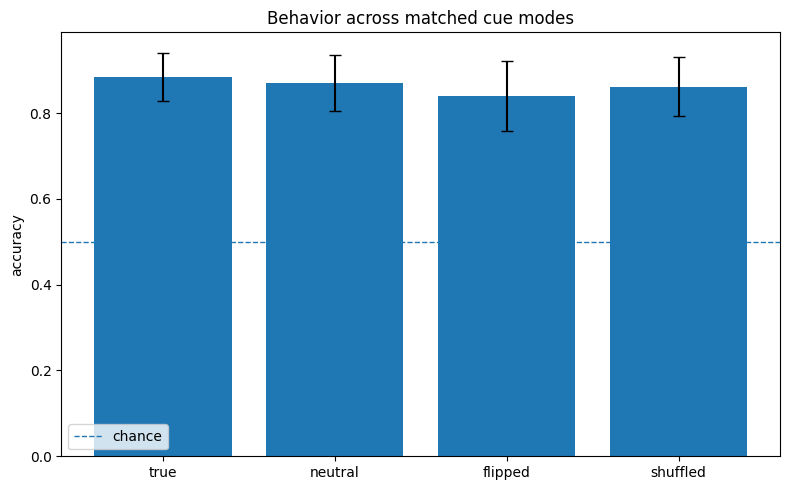

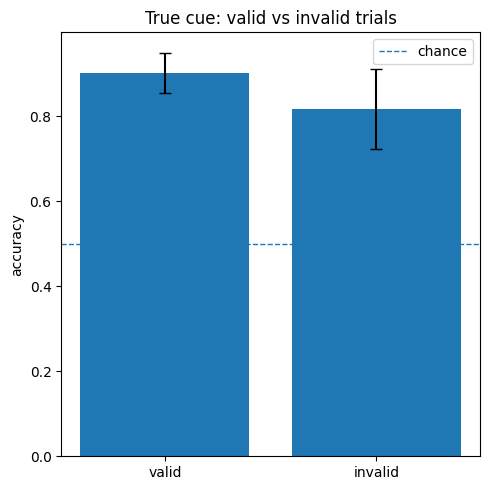

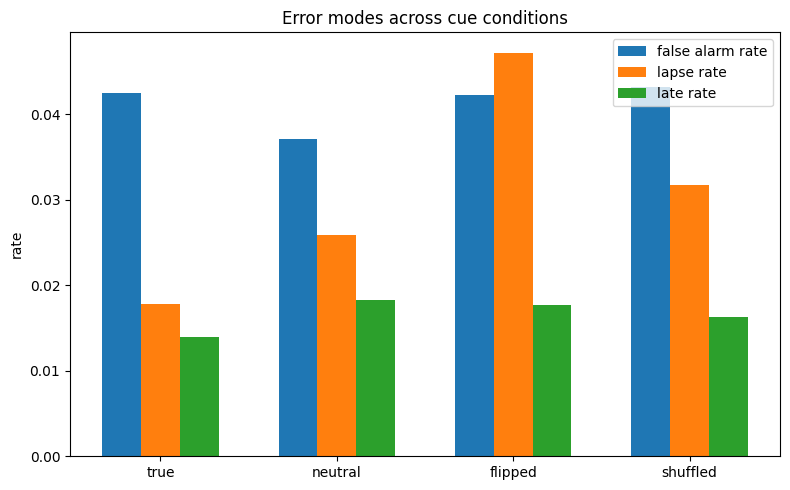

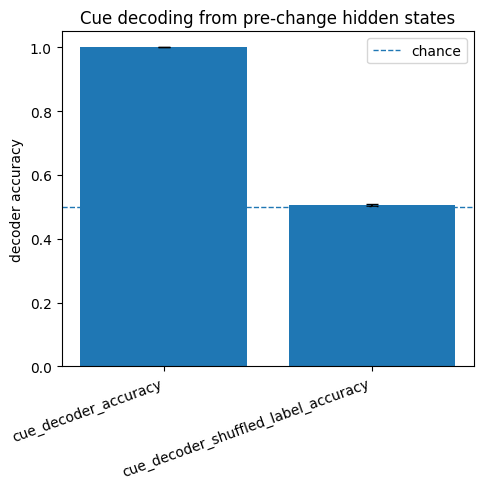

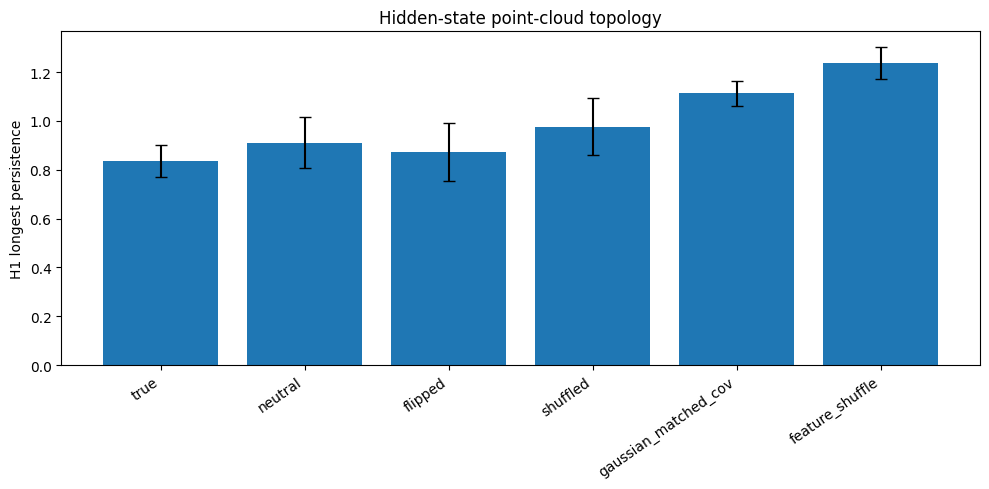

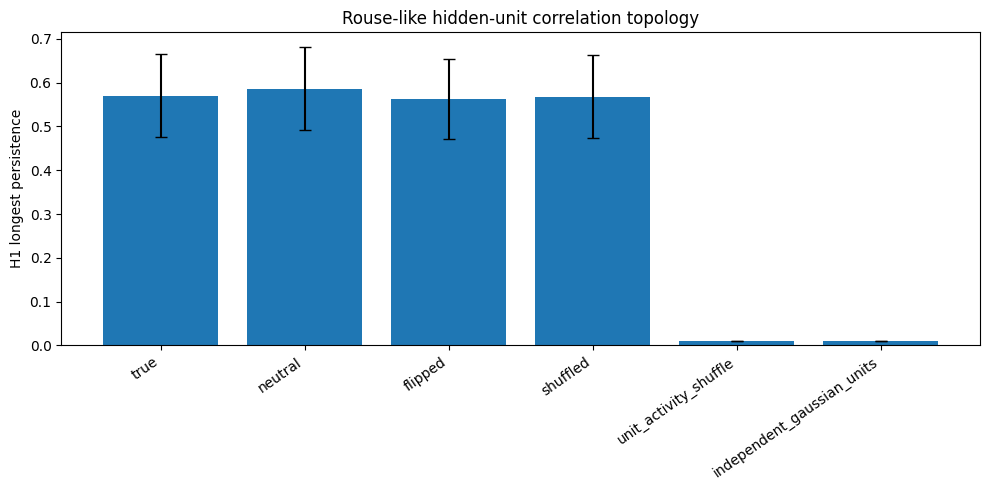

In [12]:
fig_dir = RESULTS_DIR / "figures"

# Behavior mean/SEM plot
order = ["true", "neutral", "flipped", "shuffled"]
plot_df = behavior_summary.set_index("cue_mode").reindex(order).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["cue_mode"], plot_df["accuracy_mean"], yerr=plot_df["accuracy_sem"], capsize=4)
plt.axhline(0.5, linestyle="--", linewidth=1, label="chance")
plt.ylabel("accuracy")
plt.title("Behavior across matched cue modes")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "behavior_mean_sem_by_mode.png", dpi=250)
plt.show()

# Valid vs invalid for true cue only
true_rows = all_behavior[all_behavior["cue_mode"] == "true"]
vi_summary = pd.DataFrame({
    "condition": ["valid", "invalid"],
    "mean": [true_rows["valid_accuracy"].mean(), true_rows["invalid_accuracy"].mean()],
    "sem": [true_rows["valid_accuracy"].sem(), true_rows["invalid_accuracy"].sem()],
})
plt.figure(figsize=(5, 5))
plt.bar(vi_summary["condition"], vi_summary["mean"], yerr=vi_summary["sem"], capsize=4)
plt.axhline(0.5, linestyle="--", linewidth=1, label="chance")
plt.ylabel("accuracy")
plt.title("True cue: valid vs invalid trials")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "valid_vs_invalid_true_cue.png", dpi=250)
plt.show()

# False alarm / lapse rates
metric_order = ["false_alarm_rate", "lapse_rate", "late_rate"]
plt.figure(figsize=(8, 5))
for i, metric in enumerate(metric_order):
    vals = [plot_df[f"{metric}_mean"].iloc[j] for j in range(len(plot_df))]
    x = np.arange(len(plot_df)) + (i - 1) * 0.22
    plt.bar(x, vals, width=0.22, label=metric.replace("_", " "))
plt.xticks(np.arange(len(plot_df)), plot_df["cue_mode"])
plt.ylabel("rate")
plt.title("Error modes across cue conditions")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "false_alarm_lapse_late_rates.png", dpi=250)
plt.show()

# Cue decoder figure
plt.figure(figsize=(5, 5))
plt.bar(decoder_summary["metric"], decoder_summary["mean"], yerr=decoder_summary["sem"], capsize=4)
plt.axhline(0.5, linestyle="--", linewidth=1, label="chance")
plt.xticks(rotation=20, ha="right")
plt.ylabel("decoder accuracy")
plt.title("Cue decoding from pre-change hidden states")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "cue_decoder_mean_sem.png", dpi=250)
plt.show()

# Hidden-state H1 figure
if RUN_TOPOLOGY and not hidden_H1_summary.empty:
    h_order = ["true", "neutral", "flipped", "shuffled", "gaussian_matched_cov", "feature_shuffle"]
    hplot = hidden_H1_summary.set_index("condition").reindex([x for x in h_order if x in hidden_H1_summary["condition"].values]).reset_index()
    plt.figure(figsize=(10, 5))
    plt.bar(hplot["condition"], hplot["longest_persistence_mean"], yerr=hplot["longest_persistence_sem"], capsize=4)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("H1 longest persistence")
    plt.title("Hidden-state point-cloud topology")
    plt.tight_layout()
    plt.savefig(fig_dir / "hidden_state_H1_longest_mean_sem.png", dpi=250)
    plt.show()

# Rouse-like H1 figure
if RUN_TOPOLOGY and not rouse_H1_summary.empty:
    r_order = ["true", "neutral", "flipped", "shuffled", "unit_activity_shuffle", "independent_gaussian_units"]
    rplot = rouse_H1_summary.set_index("condition").reindex([x for x in r_order if x in rouse_H1_summary["condition"].values]).reset_index()
    plt.figure(figsize=(10, 5))
    plt.bar(rplot["condition"], rplot["longest_persistence_mean"], yerr=rplot["longest_persistence_sem"], capsize=4)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("H1 longest persistence")
    plt.title("Rouse-like hidden-unit correlation topology")
    plt.tight_layout()
    plt.savefig(fig_dir / "rouse_like_H1_longest_mean_sem.png", dpi=250)
    plt.show()

## 10. Automatic interpretation and report

The report below is saved as `summary_report.md` in the results folder. It uses the actual numbers from your run.

In [13]:
def safe_get_summary(df, mode, metric):
    row = df[df["cue_mode"] == mode]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][f"{metric}_mean"])

def safe_get_summary_sem(df, mode, metric):
    row = df[df["cue_mode"] == mode]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][f"{metric}_sem"])

true_acc = safe_get_summary(behavior_summary, "true", "accuracy")
neutral_acc = safe_get_summary(behavior_summary, "neutral", "accuracy")
flipped_acc = safe_get_summary(behavior_summary, "flipped", "accuracy")
shuffled_acc = safe_get_summary(behavior_summary, "shuffled", "accuracy")
true_valid = safe_get_summary(behavior_summary, "true", "valid_accuracy")
true_invalid = safe_get_summary(behavior_summary, "true", "invalid_accuracy")
true_fa = safe_get_summary(behavior_summary, "true", "false_alarm_rate")
true_lapse = safe_get_summary(behavior_summary, "true", "lapse_rate")
true_dprime = safe_get_summary(behavior_summary, "true", "dprime")

report = f"""
# GRU Cued Change-Detection Final Run Report

## Configuration

- Training method: supervised learning
- Model: single-layer GRU with two heads
  - response head: wait vs respond
  - side head: left vs right
- Cue input: 3 channels
  - left cue = [1,0,0]
  - right cue = [0,1,0]
  - neutral cue = [0,0,1]
- Cue is transient: visible only during the cue period.
- Training cue validity: {ENV_CFG.train_cue_validity}
- Evaluation cue validity: {ENV_CFG.eval_cue_validity}
- Change amplitude range: {ENV_CFG.change_amp_low} to {ENV_CFG.change_amp_high}
- Noise std: {ENV_CFG.noise_std}
- Response/evidence window: {ENV_CFG.response_window} timesteps
- Wait loss weight: {TRAIN_CFG.wait_loss_weight}
- Respond loss weight: {TRAIN_CFG.respond_loss_weight}
- Pre-change response target: {TRAIN_CFG.prechange_response_target}
- Pre-change response penalty weight: {TRAIN_CFG.prechange_response_penalty_weight}
- Threshold-selection score: accuracy - 2*false_alarm_rate - 0.5*lapse_rate
- Threshold grid: {TRAIN_CFG.response_threshold_grid}
- Invalid-trial side loss weight: {TRAIN_CFG.invalid_side_weight}
- Seeds: {SEEDS}

## Main behavior results

Mean across seeds:

- True cue accuracy: {true_acc:.3f}
- Neutral cue accuracy: {neutral_acc:.3f}
- Flipped cue accuracy: {flipped_acc:.3f}
- Shuffled cue accuracy: {shuffled_acc:.3f}
- True-cue valid accuracy: {true_valid:.3f}
- True-cue invalid accuracy: {true_invalid:.3f}
- True-cue false alarm rate: {true_fa:.3f}
- True-cue lapse rate: {true_lapse:.3f}
- True-cue d-prime: {true_dprime:.3f}

## Desired behavioral pattern

The intended result after the threshold/loss rebalance is:

```text
true cue > neutral/shuffled/flipped cue
valid > invalid > chance
false alarms low/moderate
d-prime positive
```

## Interpretation guide

- If true cue accuracy is greater than neutral/shuffled/flipped, the cue direction is behaviorally useful.
- If invalid accuracy remains above chance, the model is not blindly following the cue.
- If false alarm rate is low/moderate, the wait-vs-respond head is working.
- If shuffled cue accuracy is close to true cue accuracy, the environment may still be solvable mostly from stimulus evidence.
- If invalid accuracy is near zero, the model is relying too strongly on the cue.

## Topological analyses

Two analyses were run:

1. Hidden-state point-cloud topology:
   - point = one full GRU hidden-state vector
   - metric = Euclidean distance after shared standardization/PCA
   - main metric = H1 longest persistence

2. Rouse-like hidden-unit correlation topology:
   - vertex = one GRU hidden unit
   - distance = 1 - correlation between hidden units
   - main metric = H1 longest persistence and peak Betti values

Files saved in this run:

- csv/behavior_mean_sem_by_mode.csv
- csv/paired_behavior_differences.csv
- csv/cue_decoder_mean_sem.csv
- csv/hidden_state_H1_mean_sem.csv
- csv/rouse_like_H1_mean_sem.csv
- figures/behavior_mean_sem_by_mode.png
- figures/valid_vs_invalid_true_cue.png
- figures/false_alarm_lapse_late_rates.png
- figures/cue_decoder_mean_sem.png
- figures/hidden_state_H1_longest_mean_sem.png
- figures/rouse_like_H1_longest_mean_sem.png
""".strip()

with open(RESULTS_DIR / "summary_report.md", "w") as f:
    f.write(report)

print(report)

# GRU Cued Change-Detection Final Run Report

## Configuration

- Training method: supervised learning
- Model: single-layer GRU with two heads
  - response head: wait vs respond
  - side head: left vs right
- Cue input: 3 channels
  - left cue = [1,0,0]
  - right cue = [0,1,0]
  - neutral cue = [0,0,1]
- Cue is transient: visible only during the cue period.
- Training cue validity: 0.72
- Evaluation cue validity: 0.8
- Change amplitude range: 0.14 to 0.18
- Noise std: 0.048
- Response/evidence window: 12 timesteps
- Wait loss weight: 2.5
- Respond loss weight: 2.25
- Pre-change response target: 0.18
- Pre-change response penalty weight: 5.0
- Threshold-selection score: accuracy - 2*false_alarm_rate - 0.5*lapse_rate
- Threshold grid: (0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9)
- Invalid-trial side loss weight: 2.0
- Seeds: [0, 1, 2, 3, 4]

## Main behavior results

Mean across seeds:

- True cue accuracy: 0.884
- Neutral cue accuracy: 0.871
- Flipped cue accuracy: 0.841
- Shuffle


## 11. Cue-specific topology extensions

The earlier topology sections measured general hidden-state and hidden-unit structure. The two analyses below are more directly tied to cue-dependent attention:

1. **Cue-induced hidden-state difference topology**: run persistent homology on matched hidden-state differences such as

\[
\Delta h = h_{\text{true cue}} - h_{\text{neutral cue}}.
\]

This isolates the part of the hidden state caused by the cue manipulation while keeping the stimulus stream, noise, changed side, and change time matched.

2. **Preferred-stream Rouse-like topology**: estimate whether each GRU hidden unit is more sensitive to the left or right stimulus stream. Then compare hidden-unit correlation topology when the cue points toward the preferred stream versus away from it.


In [14]:

# ---------------------------------------------------------------------
# Cue-specific topology extension 1:
# Topology of cue-induced hidden-state differences.
# ---------------------------------------------------------------------

def make_delta_nulls(delta_X, seed=0):
    """Nulls for cue-induced hidden-state differences."""
    rng = np.random.default_rng(seed)
    X = np.asarray(delta_X, dtype=np.float64)
    nulls = {}

    # Matched Gaussian in delta space.
    mu = X.mean(axis=0)
    cov = np.cov(X, rowvar=False) + 1e-6 * np.eye(X.shape[1])
    nulls["delta_gaussian_matched_cov"] = rng.multivariate_normal(mu, cov, size=len(X)).astype(np.float32)

    # Feature-shuffled delta: preserves marginal distribution per component but destroys joint geometry.
    X_feat = X.copy()
    for j in range(X_feat.shape[1]):
        rng.shuffle(X_feat[:, j])
    nulls["delta_feature_shuffle"] = X_feat.astype(np.float32)

    # Sign-flip null: preserves magnitudes but randomizes direction of cue effect for each sample.
    signs = rng.choice([-1.0, 1.0], size=(len(X), 1))
    nulls["delta_random_sign_flip"] = (X * signs).astype(np.float32)

    return nulls


def run_cue_delta_topology_for_seed(seed, env_cfg, train_cfg, tda_cfg, results_dir):
    """
    Re-load the trained seed model and compute topology on matched cue-induced hidden-state differences.

    Uses the same trained model and environment configuration as the main analysis.
    """
    seed_dir = results_dir / f"seed_{seed:02d}"
    topology_dir = seed_dir / "topology" / "cue_delta_hidden_state"
    topology_dir.mkdir(parents=True, exist_ok=True)

    env = CuedChangeDetectionEnv(env_cfg, seed=seed)
    model = TwoHeadGRUPolicy(input_size=env_cfg.input_size, hidden_size=train_cfg.hidden_size).to(DEVICE)
    state_path = seed_dir / "final_model.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"Missing trained model: {state_path}")
    model.load_state_dict(torch.load(state_path, map_location=DEVICE))
    model.eval()

    # Matched trials: same stimulus/noise/change time across cue modes.
    trials = env.generate_trials(tda_cfg.n_tda_trials, split="eval", exact_validity=env_cfg.eval_cue_validity)

    hidden_by_mode = {}
    df_by_mode = {}
    for mode in ["true", "neutral", "flipped", "shuffled"]:
        X, dfh = collect_prechange_hidden_states(model, env, trials, cue_mode=mode, device=DEVICE)
        hidden_by_mode[mode] = X
        df_by_mode[mode] = dfh

    # Row-wise matched differences. These work because the same trials and same pre-change timesteps are used.
    delta_by_condition = {
        "delta_true_minus_neutral": hidden_by_mode["true"] - hidden_by_mode["neutral"],
        "delta_true_minus_flipped": hidden_by_mode["true"] - hidden_by_mode["flipped"],
        "delta_true_minus_shuffled": hidden_by_mode["true"] - hidden_by_mode["shuffled"],
    }

    # Row-permutation null: destroys the one-to-one matching between true and neutral cue hidden states.
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(hidden_by_mode["true"]))
    delta_by_condition["delta_rowperm_true_minus_neutral"] = hidden_by_mode["true"][perm] - hidden_by_mode["neutral"]

    # Additional nulls based on the main true-neutral cue effect.
    delta_by_condition.update(make_delta_nulls(delta_by_condition["delta_true_minus_neutral"], seed=seed))

    # Shared transform for fair comparison across delta conditions.
    _, _, delta_transformed = fit_shared_hidden_transform(
        delta_by_condition,
        pca_dims=tda_cfg.pca_dims_for_hidden_tda,
    )

    rows = []
    for condition, X_delta in delta_transformed.items():
        dgms, summary = hidden_pointcloud_tda(
            X_delta,
            max_points=tda_cfg.max_hidden_points,
            maxdim=tda_cfg.hidden_maxdim,
            seed=seed,
        )
        summary["seed"] = seed
        summary["analysis"] = "cue_delta_hidden_state_pointcloud"
        summary["condition"] = condition
        rows.append(summary)

        plot_betti_curves(
            dgms,
            f"Cue-delta hidden-state Betti: {condition}, seed {seed}",
            topology_dir / f"cue_delta_betti_{condition}.png",
        )
        plot_persistence_diagram(
            dgms,
            f"Cue-delta hidden-state persistence: {condition}, seed {seed}",
            topology_dir / f"cue_delta_pd_{condition}.png",
        )

    out = pd.concat(rows, ignore_index=True)
    out.to_csv(seed_dir / "cue_delta_hidden_state_topology.csv", index=False)
    return out


# ---------------------------------------------------------------------
# Cue-specific topology extension 2:
# Unit-specific preferred-stream Rouse-like topology.
# ---------------------------------------------------------------------

@torch.no_grad()
def get_hidden_array(model, obs_np, device="cpu"):
    obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
    _, _, hidden, _ = model(obs)
    return hidden.detach().cpu().numpy()


def perturb_prechange_stimuli(obs_np, trials, env_cfg, stream="left", delta=0.03, sign=1.0):
    """Perturb one stimulus stream during the pre-change window only."""
    obs2 = obs_np.copy()
    stim_idx = 3 if stream == "left" else 4  # cue channels 0:3, left stim 3, right stim 4, phase 5
    n = obs2.shape[0]
    for i in range(n):
        ctime = int(trials["change_time"][i])
        start = env_cfg.cue_duration
        end = ctime
        obs2[i, start:end, stim_idx] = obs2[i, start:end, stim_idx] + sign * delta
    obs2[:, :, stim_idx] = np.clip(obs2[:, :, stim_idx], 0.0, 1.0)
    return obs2


def flatten_prechange_differences(diff_H, trials, env_cfg):
    """Flatten hidden-state differences over pre-change timesteps."""
    rows = []
    n = diff_H.shape[0]
    for i in range(n):
        ctime = int(trials["change_time"][i])
        for t in range(env_cfg.cue_duration, ctime):
            rows.append(diff_H[i, t])
    return np.asarray(rows, dtype=np.float32)


def compute_unit_stream_preference(model, env, trials, perturb_delta=0.03, device="cpu"):
    """
    Estimate each hidden unit's sensitivity to the left and right input streams.

    Uses a symmetric finite-difference perturbation during the pre-change window:

        sensitivity_left_i = mean |h_i(left + delta) - h_i(left - delta)| / (2 delta)
        sensitivity_right_i = mean |h_i(right + delta) - h_i(right - delta)| / (2 delta)
    """
    obs_base, _ = env.build_observations(trials, cue_mode="true")

    obs_l_plus = perturb_prechange_stimuli(obs_base, trials, env.cfg, stream="left", delta=perturb_delta, sign=+1.0)
    obs_l_minus = perturb_prechange_stimuli(obs_base, trials, env.cfg, stream="left", delta=perturb_delta, sign=-1.0)
    obs_r_plus = perturb_prechange_stimuli(obs_base, trials, env.cfg, stream="right", delta=perturb_delta, sign=+1.0)
    obs_r_minus = perturb_prechange_stimuli(obs_base, trials, env.cfg, stream="right", delta=perturb_delta, sign=-1.0)

    H_l_plus = get_hidden_array(model, obs_l_plus, device=device)
    H_l_minus = get_hidden_array(model, obs_l_minus, device=device)
    H_r_plus = get_hidden_array(model, obs_r_plus, device=device)
    H_r_minus = get_hidden_array(model, obs_r_minus, device=device)

    dH_left = (H_l_plus - H_l_minus) / (2.0 * perturb_delta)
    dH_right = (H_r_plus - H_r_minus) / (2.0 * perturb_delta)

    flat_left = flatten_prechange_differences(dH_left, trials, env.cfg)
    flat_right = flatten_prechange_differences(dH_right, trials, env.cfg)

    left_sensitivity = np.mean(np.abs(flat_left), axis=0)
    right_sensitivity = np.mean(np.abs(flat_right), axis=0)
    preference_score = left_sensitivity - right_sensitivity
    preferred_stream = np.where(preference_score >= 0, SIDE_LEFT, SIDE_RIGHT)

    pref_df = pd.DataFrame({
        "unit": np.arange(len(left_sensitivity)),
        "left_sensitivity": left_sensitivity,
        "right_sensitivity": right_sensitivity,
        "preference_score_left_minus_right": preference_score,
        "preferred_stream": preferred_stream,
        "preferred_stream_name": np.where(preferred_stream == SIDE_LEFT, "left", "right"),
    })
    return pref_df


def run_preferred_stream_rouse_topology_for_seed(seed, env_cfg, train_cfg, tda_cfg, results_dir):
    """
    Identify left- vs right-sensitive hidden units, then run Rouse-like topology on:

    - left-preferring units during left-cue trials   = attend preferred
    - left-preferring units during right-cue trials  = attend away
    - right-preferring units during right-cue trials = attend preferred
    - right-preferring units during left-cue trials  = attend away
    """
    seed_dir = results_dir / f"seed_{seed:02d}"
    topology_dir = seed_dir / "topology" / "preferred_stream_rouse_like"
    topology_dir.mkdir(parents=True, exist_ok=True)

    env = CuedChangeDetectionEnv(env_cfg, seed=seed)
    model = TwoHeadGRUPolicy(input_size=env_cfg.input_size, hidden_size=train_cfg.hidden_size).to(DEVICE)
    state_path = seed_dir / "final_model.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"Missing trained model: {state_path}")
    model.load_state_dict(torch.load(state_path, map_location=DEVICE))
    model.eval()

    trials = env.generate_trials(tda_cfg.n_tda_trials, split="eval", exact_validity=env_cfg.eval_cue_validity)

    # Unit preference from finite-difference sensitivity.
    pref_df = compute_unit_stream_preference(
        model,
        env,
        trials,
        perturb_delta=0.03,
        device=DEVICE,
    )
    pref_df["seed"] = seed
    pref_df.to_csv(seed_dir / "unit_stream_preference.csv", index=False)

    # Save preference count plot.
    plt.figure(figsize=(5, 4))
    counts = pref_df["preferred_stream_name"].value_counts().reindex(["left", "right"]).fillna(0)
    plt.bar(counts.index, counts.values)
    plt.ylabel("number of hidden units")
    plt.title(f"Hidden-unit preferred stream, seed {seed}")
    plt.tight_layout()
    plt.savefig(topology_dir / "unit_preferred_stream_counts.png", dpi=200)
    plt.close()

    # Hidden activity from true cue condition only.
    X_true, df_true = collect_prechange_hidden_states(model, env, trials, cue_mode="true", device=DEVICE)

    left_units = pref_df.loc[pref_df["preferred_stream"] == SIDE_LEFT, "unit"].to_numpy(dtype=int)
    right_units = pref_df.loc[pref_df["preferred_stream"] == SIDE_RIGHT, "unit"].to_numpy(dtype=int)

    masks = {
        "left_cue": df_true["true_cue_side"].to_numpy() == SIDE_LEFT,
        "right_cue": df_true["true_cue_side"].to_numpy() == SIDE_RIGHT,
    }

    configs = [
        ("left_pref_attend_preferred", left_units, masks["left_cue"], "left_pref", "attend_preferred"),
        ("left_pref_attend_away", left_units, masks["right_cue"], "left_pref", "attend_away"),
        ("right_pref_attend_preferred", right_units, masks["right_cue"], "right_pref", "attend_preferred"),
        ("right_pref_attend_away", right_units, masks["left_cue"], "right_pref", "attend_away"),
    ]

    rows = []
    for condition, units, sample_mask, unit_group, attention_condition in configs:
        if len(units) < 4 or sample_mask.sum() < 20:
            # Not enough units/samples for a meaningful topology estimate.
            summary = pd.DataFrame([{
                "homology_dim": "H1",
                "num_features": 0,
                "longest_persistence": np.nan,
                "total_persistence": np.nan,
                "peak_betti": np.nan,
            }])
            summary["seed"] = seed
            summary["analysis"] = "preferred_stream_rouse_like"
            summary["condition"] = condition
            summary["unit_group"] = unit_group
            summary["attention_condition"] = attention_condition
            summary["n_units"] = len(units)
            summary["n_samples"] = int(sample_mask.sum())
            rows.append(summary)
            continue

        X_sub = X_true[sample_mask][:, units]
        df_sub = df_true.loc[sample_mask].reset_index(drop=True)

        dgms, summary, C, D = rouse_like_unit_tda(
            X_sub,
            df=df_sub,
            residualize=True,
            seed=seed,
            maxdim=min(tda_cfg.unit_maxdim, 2),
        )
        summary["seed"] = seed
        summary["analysis"] = "preferred_stream_rouse_like"
        summary["condition"] = condition
        summary["unit_group"] = unit_group
        summary["attention_condition"] = attention_condition
        summary["n_units"] = len(units)
        summary["n_samples"] = int(sample_mask.sum())
        rows.append(summary)

        plot_betti_curves(
            dgms,
            f"Preferred-stream Rouse-like Betti: {condition}, seed {seed}",
            topology_dir / f"preferred_stream_betti_{condition}.png",
        )
        plot_persistence_diagram(
            dgms,
            f"Preferred-stream Rouse-like persistence: {condition}, seed {seed}",
            topology_dir / f"preferred_stream_pd_{condition}.png",
        )

    out = pd.concat(rows, ignore_index=True)
    out.to_csv(seed_dir / "preferred_stream_rouse_like_topology.csv", index=False)
    return out, pref_df



## 12. Run the two cue-specific topology extensions

This section re-loads the trained models saved above and runs the two additional analyses without changing training.


In [15]:

# Run added cue-specific topology analyses across seeds.
cue_delta_results = []
preferred_rouse_results = []
unit_preference_results = []

if RUN_TOPOLOGY:
    for seed in SEEDS:
        print("\n" + "-"*80)
        print(f"Cue-specific topology extensions, seed {seed}")
        print("-"*80)

        delta_df = run_cue_delta_topology_for_seed(seed, ENV_CFG, TRAIN_CFG, TDA_CFG, RESULTS_DIR)
        cue_delta_results.append(delta_df)

        pref_top_df, pref_df = run_preferred_stream_rouse_topology_for_seed(seed, ENV_CFG, TRAIN_CFG, TDA_CFG, RESULTS_DIR)
        preferred_rouse_results.append(pref_top_df)
        unit_preference_results.append(pref_df)

    all_cue_delta_top = pd.concat(cue_delta_results, ignore_index=True)
    all_pref_rouse_top = pd.concat(preferred_rouse_results, ignore_index=True)
    all_unit_preferences = pd.concat(unit_preference_results, ignore_index=True)
else:
    all_cue_delta_top = pd.DataFrame()
    all_pref_rouse_top = pd.DataFrame()
    all_unit_preferences = pd.DataFrame()

# Save raw results.
all_cue_delta_top.to_csv(csv_dir / "all_seed_cue_delta_hidden_state_topology.csv", index=False)
all_pref_rouse_top.to_csv(csv_dir / "all_seed_preferred_stream_rouse_like_topology.csv", index=False)
all_unit_preferences.to_csv(csv_dir / "all_seed_unit_stream_preferences.csv", index=False)

# Summaries.
if RUN_TOPOLOGY and not all_cue_delta_top.empty:
    cue_delta_H1 = all_cue_delta_top[all_cue_delta_top["homology_dim"] == "H1"].copy()
    cue_delta_H1_summary = mean_sem(
        cue_delta_H1,
        ["condition"],
        ["longest_persistence", "peak_betti", "total_persistence"],
    )
    cue_delta_H1_summary.to_csv(csv_dir / "cue_delta_H1_mean_sem.csv", index=False)
else:
    cue_delta_H1_summary = pd.DataFrame()

if RUN_TOPOLOGY and not all_pref_rouse_top.empty:
    pref_rouse_H1 = all_pref_rouse_top[all_pref_rouse_top["homology_dim"] == "H1"].copy()
    preferred_rouse_H1_summary = mean_sem(
        pref_rouse_H1,
        ["condition", "unit_group", "attention_condition"],
        ["longest_persistence", "peak_betti", "total_persistence"],
    )
    preferred_rouse_H1_summary.to_csv(csv_dir / "preferred_stream_rouse_H1_mean_sem.csv", index=False)

    # Paired preferred-vs-away differences per seed and unit group.
    pair_rows = []
    for (seed, unit_group), g in pref_rouse_H1.groupby(["seed", "unit_group"]):
        vals = {row["attention_condition"]: row for _, row in g.iterrows()}
        if "attend_preferred" in vals and "attend_away" in vals:
            pair_rows.append({
                "seed": seed,
                "unit_group": unit_group,
                "preferred_minus_away_H1_longest": vals["attend_preferred"]["longest_persistence"] - vals["attend_away"]["longest_persistence"],
                "preferred_minus_away_peak_betti": vals["attend_preferred"]["peak_betti"] - vals["attend_away"]["peak_betti"],
                "preferred_H1_longest": vals["attend_preferred"]["longest_persistence"],
                "away_H1_longest": vals["attend_away"]["longest_persistence"],
            })
    preferred_vs_away_pairs = pd.DataFrame(pair_rows)
    preferred_vs_away_pairs.to_csv(csv_dir / "preferred_vs_away_rouse_H1_paired_differences.csv", index=False)
else:
    preferred_rouse_H1_summary = pd.DataFrame()
    preferred_vs_away_pairs = pd.DataFrame()

# Unit preference summary.
if not all_unit_preferences.empty:
    unit_pref_summary = all_unit_preferences.groupby(["seed", "preferred_stream_name"]).size().reset_index(name="n_units")
    unit_pref_summary.to_csv(csv_dir / "unit_preference_counts_by_seed.csv", index=False)
else:
    unit_pref_summary = pd.DataFrame()

print("Cue-delta H1 summary:")
display(cue_delta_H1_summary)
print("Preferred-stream Rouse-like H1 summary:")
display(preferred_rouse_H1_summary)
print("Preferred-vs-away paired H1 differences:")
display(preferred_vs_away_pairs)
print("Unit preference counts:")
display(unit_pref_summary)



--------------------------------------------------------------------------------
Cue-specific topology extensions, seed 0
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Cue-specific topology extensions, seed 1
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Cue-specific topology extensions, seed 2
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Cue-specific topology extensions, seed 3
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Cue-specific topology extensions, seed 4
-------------------------------------------------------------

,condition,longest_persistence_mean,longest_persistence_sem,longest_persistence_n,peak_betti_mean,peak_betti_sem,peak_betti_n,total_persistence_mean,total_persistence_sem,total_persistence_n
0,delta_feature_shuffle,0.256434,0.033080,5,91.0,8.786353,5,23.951103,0.957709,5
1,delta_gaussian_matched_cov,0.285430,0.012007,5,135.8,6.110646,5,33.329773,1.858880,5
2,delta_random_sign_flip,0.194765,0.027150,5,18.4,3.722902,5,3.227841,0.539189,5
3,delta_rowperm_true_minus_neutral,3.498754,0.569155,5,68.2,5.704384,5,255.829293,26.303704,5
4,delta_true_minus_flipped,0.161249,0.015206,5,28.4,5.418487,5,5.254817,0.561113,5
5,delta_true_minus_neutral,0.103532,0.025164,5,26.2,4.465423,5,3.190055,0.397237,5
6,delta_true_minus_shuffled,0.145789,0.031279,5,14.0,2.449490,5,2.298378,0.315021,5


Preferred-stream Rouse-like H1 summary:


,condition,unit_group,attention_condition,longest_persistence_mean,longest_persistence_sem,longest_persistence_n,peak_betti_mean,peak_betti_sem,peak_betti_n,total_persistence_mean,total_persistence_sem,total_persistence_n
0,left_pref_attend_away,left_pref,attend_away,0.414951,0.070666,5,3.00,0.707107,5,0.797123,0.218667,5
1,left_pref_attend_preferred,left_pref,attend_preferred,0.397992,0.063557,5,2.80,0.583095,5,0.788242,0.215046,5
2,right_pref_attend_away,right_pref,attend_away,0.557182,0.117169,4,3.00,0.408248,4,0.832822,0.050753,4
3,right_pref_attend_preferred,right_pref,attend_preferred,0.604122,0.089399,4,2.25,0.478714,4,0.868957,0.052577,4


Preferred-vs-away paired H1 differences:


,seed,unit_group,preferred_minus_away_H1_longest,preferred_minus_away_peak_betti,preferred_H1_longest,away_H1_longest
0,0,left_pref,-0.073676,0.0,0.325074,0.398750
1,0,right_pref,0.130228,0.0,0.401077,0.270850
2,1,left_pref,0.004028,-1.0,0.595694,0.591666
3,1,right_pref,NaN,NaN,NaN,NaN
4,2,left_pref,0.080080,0.0,0.246144,0.166063
5,2,right_pref,-0.015035,-1.0,0.796633,0.811668
6,3,left_pref,-0.092524,0.0,0.331017,0.423541
7,3,right_pref,0.036487,-1.0,0.703099,0.666611
8,4,left_pref,-0.002699,0.0,0.492033,0.494732
9,4,right_pref,0.036082,-1.0,0.515680,0.479598


Unit preference counts:


,seed,preferred_stream_name,n_units
0,0,left,37
1,0,right,27
2,1,left,64
3,2,left,7
4,2,right,57
5,3,left,29
6,3,right,35
7,4,left,41
8,4,right,23



## 13. Save figures for the two cue-specific topology extensions


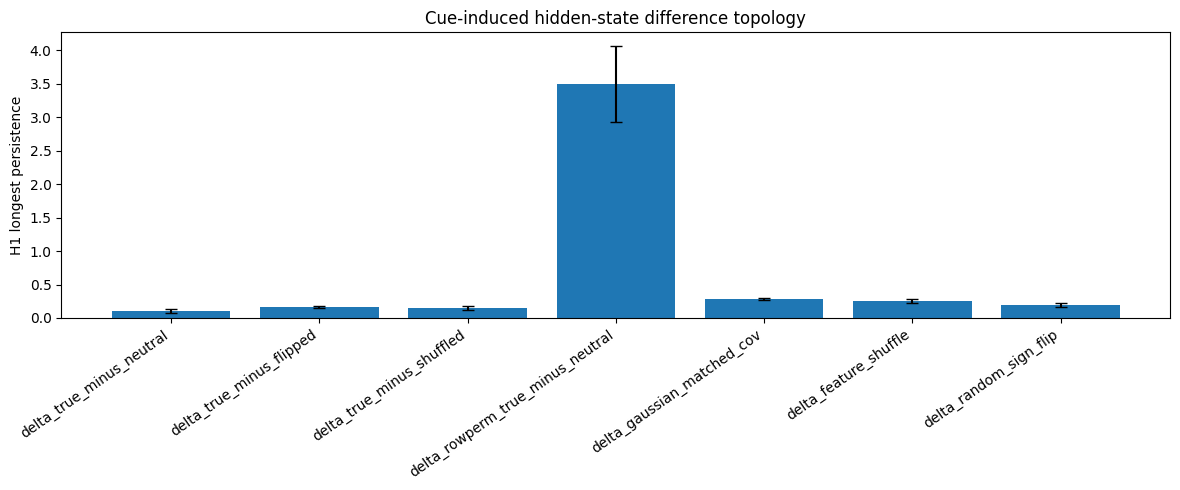

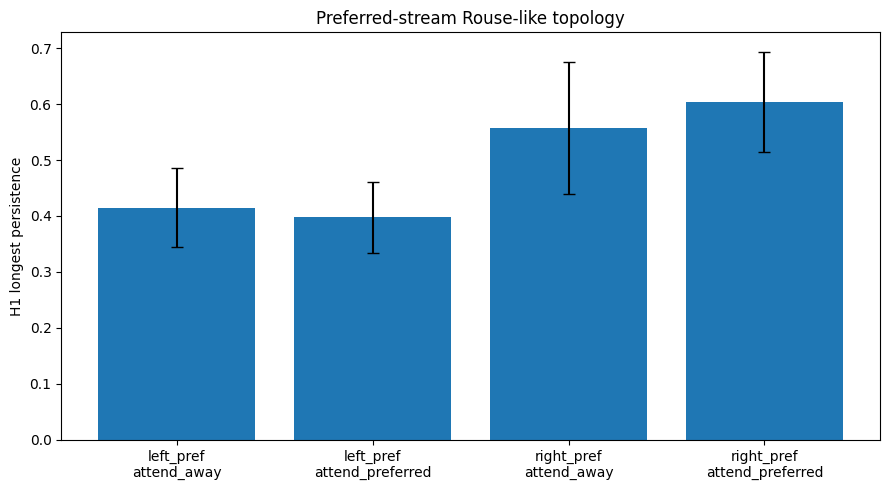

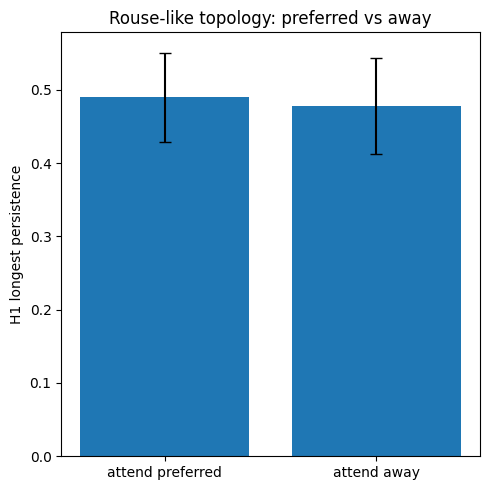

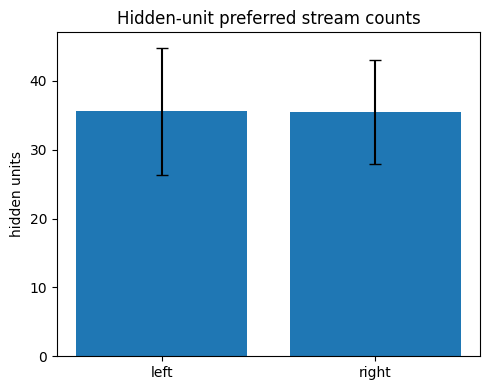

In [16]:

# Figures for cue-induced hidden-state difference topology and preferred-stream Rouse-like topology.

fig_dir = RESULTS_DIR / "figures"

if RUN_TOPOLOGY and not cue_delta_H1_summary.empty:
    delta_order = [
        "delta_true_minus_neutral",
        "delta_true_minus_flipped",
        "delta_true_minus_shuffled",
        "delta_rowperm_true_minus_neutral",
        "delta_gaussian_matched_cov",
        "delta_feature_shuffle",
        "delta_random_sign_flip",
    ]
    dplot = cue_delta_H1_summary.set_index("condition").reindex(
        [x for x in delta_order if x in cue_delta_H1_summary["condition"].values]
    ).reset_index()

    plt.figure(figsize=(12, 5))
    plt.bar(dplot["condition"], dplot["longest_persistence_mean"], yerr=dplot["longest_persistence_sem"], capsize=4)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("H1 longest persistence")
    plt.title("Cue-induced hidden-state difference topology")
    plt.tight_layout()
    plt.savefig(fig_dir / "cue_delta_H1_longest_mean_sem.png", dpi=250)
    plt.show()

if RUN_TOPOLOGY and not preferred_rouse_H1_summary.empty:
    # Plot each unit group condition separately.
    pplot = preferred_rouse_H1_summary.copy()
    pplot["label"] = pplot["unit_group"] + "\n" + pplot["attention_condition"]
    pplot = pplot.sort_values(["unit_group", "attention_condition"])

    plt.figure(figsize=(9, 5))
    plt.bar(pplot["label"], pplot["longest_persistence_mean"], yerr=pplot["longest_persistence_sem"], capsize=4)
    plt.ylabel("H1 longest persistence")
    plt.title("Preferred-stream Rouse-like topology")
    plt.tight_layout()
    plt.savefig(fig_dir / "preferred_stream_rouse_H1_longest_mean_sem.png", dpi=250)
    plt.show()

if RUN_TOPOLOGY and not preferred_vs_away_pairs.empty:
    # Collapse left-pref and right-pref pairs for a simple preferred-vs-away summary.
    pref_vals = preferred_vs_away_pairs["preferred_H1_longest"].dropna()
    away_vals = preferred_vs_away_pairs["away_H1_longest"].dropna()
    labels = ["attend preferred", "attend away"]
    means = [pref_vals.mean(), away_vals.mean()]
    sems = [pref_vals.sem(), away_vals.sem()]

    plt.figure(figsize=(5, 5))
    plt.bar(labels, means, yerr=sems, capsize=4)
    plt.ylabel("H1 longest persistence")
    plt.title("Rouse-like topology: preferred vs away")
    plt.tight_layout()
    plt.savefig(fig_dir / "preferred_vs_away_rouse_H1_summary.png", dpi=250)
    plt.show()

if not all_unit_preferences.empty:
    pref_counts = all_unit_preferences.groupby(["seed", "preferred_stream_name"]).size().reset_index(name="n_units")
    count_summary = mean_sem(pref_counts, ["preferred_stream_name"], ["n_units"])
    plt.figure(figsize=(5, 4))
    plt.bar(count_summary["preferred_stream_name"], count_summary["n_units_mean"], yerr=count_summary["n_units_sem"], capsize=4)
    plt.ylabel("hidden units")
    plt.title("Hidden-unit preferred stream counts")
    plt.tight_layout()
    plt.savefig(fig_dir / "unit_preferred_stream_counts_mean_sem.png", dpi=250)
    plt.show()



## 14. Append cue-specific topology interpretation to the report


In [17]:

# Append cue-specific topology summaries to the summary report.

def get_condition_metric(summary_df, condition, metric="longest_persistence"):
    if summary_df is None or summary_df.empty:
        return np.nan
    row = summary_df[summary_df["condition"] == condition]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][f"{metric}_mean"])

# Cue-delta key values.
delta_true_neutral = get_condition_metric(cue_delta_H1_summary, "delta_true_minus_neutral")
delta_true_flipped = get_condition_metric(cue_delta_H1_summary, "delta_true_minus_flipped")
delta_true_shuffled = get_condition_metric(cue_delta_H1_summary, "delta_true_minus_shuffled")
delta_rowperm = get_condition_metric(cue_delta_H1_summary, "delta_rowperm_true_minus_neutral")
delta_gauss = get_condition_metric(cue_delta_H1_summary, "delta_gaussian_matched_cov")
delta_feat = get_condition_metric(cue_delta_H1_summary, "delta_feature_shuffle")

if not preferred_vs_away_pairs.empty:
    pref_minus_away_mean = preferred_vs_away_pairs["preferred_minus_away_H1_longest"].mean()
    pref_minus_away_sem = preferred_vs_away_pairs["preferred_minus_away_H1_longest"].sem()
else:
    pref_minus_away_mean = np.nan
    pref_minus_away_sem = np.nan

extension_report = f"""

## Added cue-specific topology analyses

This notebook adds two analyses designed to isolate cue-related topology more directly than the raw hidden-state point-cloud or raw hidden-unit correlation analyses.

### 1. Cue-induced hidden-state difference topology

For matched trials, I computed hidden-state differences such as:

```text
Δh = h_true_cue - h_neutral_cue
```

This keeps the stimulus stream, changed side, change time, and noise matched, so the difference isolates the hidden-state effect of the cue manipulation.

Mean H1 longest persistence:

- Δ true - neutral: {delta_true_neutral:.3f}
- Δ true - flipped: {delta_true_flipped:.3f}
- Δ true - shuffled: {delta_true_shuffled:.3f}
- row-permutation null: {delta_rowperm:.3f}
- Gaussian matched-covariance delta null: {delta_gauss:.3f}
- feature-shuffled delta null: {delta_feat:.3f}

Interpretation:

- If Δ true-neutral is larger than the row-permutation and shuffled/null controls, the cue-induced hidden-state displacement has structured topology.
- If it is similar to or smaller than null controls, then the cue changes hidden states, but the H1 topology of that change is not yet specifically stronger than null structure.

### 2. Preferred-stream Rouse-like hidden-unit topology

For each hidden unit, I estimated whether it was more sensitive to the left or right stream using finite-difference perturbations. Then I compared hidden-unit correlation topology when the cue pointed toward the unit group's preferred stream versus away from it.

Paired preferred-minus-away H1 longest persistence:

- mean difference: {pref_minus_away_mean:.3f}
- SEM: {pref_minus_away_sem:.3f}

Interpretation:

- A positive preferred-minus-away value suggests a Rouse-like pattern: topology differs when attention is directed toward the units' preferred input stream.
- A value near zero suggests the hidden-unit correlation topology is nonrandom but not yet specifically organized by attend-preferred versus attend-away conditions.

Files added by this extension:

- csv/all_seed_cue_delta_hidden_state_topology.csv
- csv/cue_delta_H1_mean_sem.csv
- csv/all_seed_preferred_stream_rouse_like_topology.csv
- csv/preferred_stream_rouse_H1_mean_sem.csv
- csv/preferred_vs_away_rouse_H1_paired_differences.csv
- csv/all_seed_unit_stream_preferences.csv
- figures/cue_delta_H1_longest_mean_sem.png
- figures/preferred_stream_rouse_H1_longest_mean_sem.png
- figures/preferred_vs_away_rouse_H1_summary.png
- figures/unit_preferred_stream_counts_mean_sem.png
"""

with open(RESULTS_DIR / "summary_report.md", "a") as f:
    f.write(extension_report)

print(extension_report)




## Added cue-specific topology analyses

This notebook adds two analyses designed to isolate cue-related topology more directly than the raw hidden-state point-cloud or raw hidden-unit correlation analyses.

### 1. Cue-induced hidden-state difference topology

For matched trials, I computed hidden-state differences such as:

```text
Δh = h_true_cue - h_neutral_cue
```

This keeps the stimulus stream, changed side, change time, and noise matched, so the difference isolates the hidden-state effect of the cue manipulation.

Mean H1 longest persistence:

- Δ true - neutral: 0.104
- Δ true - flipped: 0.161
- Δ true - shuffled: 0.146
- row-permutation null: 3.499
- Gaussian matched-covariance delta null: 0.285
- feature-shuffled delta null: 0.256

Interpretation:

- If Δ true-neutral is larger than the row-permutation and shuffled/null controls, the cue-induced hidden-state displacement has structured topology.
- If it is similar to or smaller than null controls, then the cue changes hidde

## 15. Zip the complete results folder

Download the resulting `.zip` file from the notebook file browser.

In [18]:
zip_path = shutil.make_archive(str(RESULTS_DIR), "zip", root_dir=RESULTS_DIR)
print("Created ZIP archive:", zip_path)
print("Results folder:", RESULTS_DIR.resolve())
print("You can download this ZIP instead of manually saving cell outputs.")

Created ZIP archive: /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232.zip
Results folder: /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232
You can download this ZIP instead of manually saving cell outputs.


Results folder: /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232
Device: cpu
Seeds: [0, 1, 2, 3, 4]
Fresh evaluation trials per seed: 1200
No GRU training will be run.

Decoding seed 0 ... trial accuracy=1.000, trial-shuffle=0.505
Decoding seed 1 ... trial accuracy=1.000, trial-shuffle=0.506
Decoding seed 2 ... trial accuracy=1.000, trial-shuffle=0.502
Decoding seed 3 ... trial accuracy=1.000, trial-shuffle=0.511
Decoding seed 4 ... trial accuracy=1.000, trial-shuffle=0.497


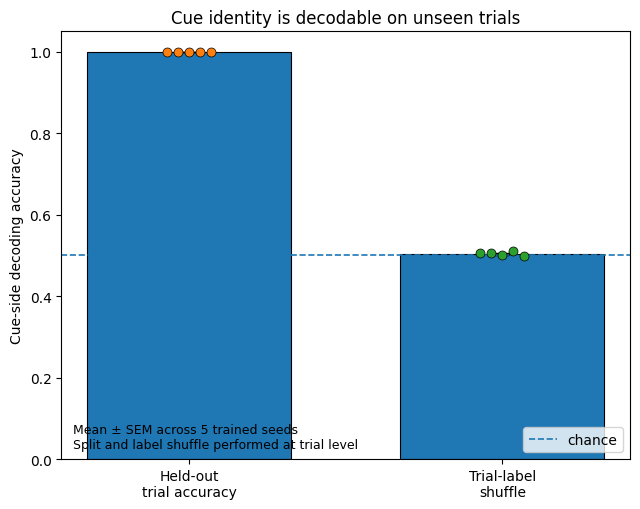


Per-seed results:


,seed,evaluation_seed,n_trials,n_train_trials,n_test_trials,n_train_states,n_test_states,cue_decoder_trial_accuracy,cue_decoder_timestep_accuracy,cue_decoder_shuffled_trial_accuracy,cue_decoder_shuffled_trial_accuracy_sd,cue_decoder_shuffled_timestep_accuracy,cue_decoder_shuffled_timestep_accuracy_sd,null_permutations,trial_overlap_count,scaler_fit_scope
0,0,100000,1200,840,360,11009,4692,1.0,0.999147,0.504861,0.025152,0.503943,0.019042,20,0,training trials only
1,1,100001,1200,840,360,10816,4613,1.0,1.000000,0.506111,0.020164,0.504010,0.013667,20,0,training trials only
2,2,100002,1200,840,360,10788,4773,1.0,0.999790,0.501528,0.021488,0.502692,0.013948,20,0,training trials only
3,3,100003,1200,840,360,11030,4700,1.0,1.000000,0.511250,0.016482,0.511021,0.015342,20,0,training trials only
4,4,100004,1200,840,360,10990,4639,1.0,1.000000,0.497361,0.022539,0.496745,0.015315,20,0,training trials only



Mean ± SEM across trained seeds:


,metric,column,mean,sem,n_seeds
0,Held-out trial accuracy,cue_decoder_trial_accuracy,1.000000,0.000000,5
1,Trial-label shuffle,cue_decoder_shuffled_trial_accuracy,0.504222,0.002321,5
2,Held-out timestep accuracy,cue_decoder_timestep_accuracy,0.999788,0.000165,5
3,Timestep trial-label shuffle,cue_decoder_shuffled_timestep_accuracy,0.503682,0.002271,5



Validation checks:
  Trial overlap across train/test folds: 0
  Scaler fit scope: training trials only
  Shuffled labels: one permuted label per trial

Saved:
  /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232/csv/all_seed_cue_decoder_trial_grouped.csv
  /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232/csv/cue_decoder_trial_grouped_mean_sem.csv
  /Users/alhamza.abu-ragheef/Documents/baml/RUN_THIS_gru_cue_specific_topology_results_20260714_014232/figures/cue_decoder_trial_grouped.png


In [1]:
# ============================================================================
# STANDALONE, LEAKAGE-SAFE CUE DECODER
# Run this cell by itself after the original training run has produced
#  It does NOT retrain the GRU.
# ============================================================================

from pathlib import Path
from types import SimpleNamespace
import json
import math
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ----------------------------- user-adjustable ------------------------------
# Leave as None to use the current RESULTS_DIR variable or auto-detect the
# newest results folder in the current working directory.
RESULTS_DIR_OVERRIDE = None
TEST_SIZE = 0.30
N_NULL_PERMUTATIONS = 20       # Increase for a smoother shuffled-label estimate.
EVAL_SEED_OFFSET = 100_000     # Ensures fresh evaluation trials, separate from training.
# ---------------------------------------------------------------------------


def _find_results_dir():
    """Locate the completed run, optionally unpacking its ZIP archive."""
    # An explicit override always wins.
    if RESULTS_DIR_OVERRIDE is not None:
        override = Path(RESULTS_DIR_OVERRIDE).expanduser().resolve()
        if override.exists() and (override / "config.json").exists():
            return override
        raise FileNotFoundError(
            f"RESULTS_DIR_OVERRIDE does not point to a completed run: {override}"
        )

    # Reuse the notebook variable when the original kernel is still alive.
    if "RESULTS_DIR" in globals():
        try:
            current_run = Path(globals()["RESULTS_DIR"]).expanduser().resolve()
            if current_run.exists() and (current_run / "config.json").exists():
                return current_run
        except Exception:
            pass

    candidates = []
    search_roots = []
    for root in (Path.cwd(), Path("/content"), Path("/mnt/data")):
        if root.exists() and root not in search_roots:
            search_roots.append(root)

    pattern = "RUN_THIS_gru_cue_specific_topology_results_*"
    for root in search_roots:
        candidates.extend(p for p in root.glob(pattern) if p.is_dir())

    valid = [
        p.resolve()
        for p in candidates
        if p.exists() and (p / "config.json").exists()
    ]
    if valid:
        return max(set(valid), key=lambda p: p.stat().st_mtime)

    # A completed notebook also creates a ZIP. Unpack it if only the archive remains.
    zip_candidates = []
    for root in search_roots:
        zip_candidates.extend(root.glob(pattern + ".zip"))
    if zip_candidates:
        zip_path = max(zip_candidates, key=lambda p: p.stat().st_mtime)
        unpack_dir = zip_path.with_suffix("")
        if not unpack_dir.exists():
            shutil.unpack_archive(str(zip_path), str(unpack_dir))
        if (unpack_dir / "config.json").exists():
            return unpack_dir.resolve()

    raise FileNotFoundError(
        "Could not find the completed results folder or ZIP. The decoder needs "
        "the saved seed_XX/final_model.pt files, but it does not need retraining. "
        "Set RESULTS_DIR_OVERRIDE at the top of this cell to the completed run folder."
    )


RUN_DIR = _find_results_dir()
with open(RUN_DIR / "config.json", "r") as f:
    _cfg = json.load(f)

ENV = SimpleNamespace(**_cfg["env"])
TRAIN = SimpleNamespace(**_cfg["train"])
SEEDS_FROM_CONFIG = [int(s) for s in _cfg.get("seeds", [])]
DEVICE_LOCAL = "cuda" if torch.cuda.is_available() else "cpu"

CUE_LEFT, CUE_RIGHT, CUE_NEUTRAL = 0, 1, 2
SIDE_LEFT, SIDE_RIGHT = 0, 1


class _DecoderEnv:
    """Minimal copy of the notebook's evaluation environment."""

    def __init__(self, cfg, seed):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)

    @staticmethod
    def _opposite_side(side):
        return SIDE_RIGHT if side == SIDE_LEFT else SIDE_LEFT

    def _choose_informative_cue(self, changed_side, cue_validity):
        if self.rng.random() < cue_validity:
            return changed_side
        return self._opposite_side(changed_side)

    def generate_eval_trials(self, n_trials):
        cfg = self.cfg
        n_trials = int(n_trials)
        T = int(cfg.seq_len)

        changed_side = self.rng.integers(0, 2, size=n_trials)
        baselines = self.rng.uniform(cfg.baseline_low, cfg.baseline_high, size=(n_trials, 2))
        amplitudes = self.rng.uniform(cfg.change_amp_low, cfg.change_amp_high, size=n_trials)
        signs = self.rng.choice([-1.0, 1.0], size=n_trials)

        latest_change_time = cfg.seq_len - cfg.response_window - cfg.post_window
        earliest_change_time = cfg.cue_duration + cfg.min_pre_change
        if latest_change_time <= earliest_change_time:
            raise ValueError("Timing configuration leaves no room for change times.")
        change_time = self.rng.integers(
            earliest_change_time, latest_change_time + 1, size=n_trials
        )

        cue_type = np.empty(n_trials, dtype=np.int64)
        true_cue_side = np.empty(n_trials, dtype=np.int64)
        valid = np.empty(n_trials, dtype=bool)

        for i in range(n_trials):
            informative_cue = self._choose_informative_cue(
                int(changed_side[i]), float(cfg.eval_cue_validity)
            )
            true_cue_side[i] = informative_cue
            valid[i] = informative_cue == changed_side[i]
            cue_type[i] = CUE_LEFT if informative_cue == SIDE_LEFT else CUE_RIGHT

        stimuli = np.zeros((n_trials, T, 2), dtype=np.float32)
        for i in range(n_trials):
            means = np.repeat(baselines[i][None, :], T, axis=0)
            ctime = int(change_time[i])
            rend = min(T, ctime + int(cfg.response_window))
            side = int(changed_side[i])
            means[ctime:rend, side] += signs[i] * amplitudes[i]

            if self.rng.random() < cfg.distractor_prob:
                max_pre = max(int(cfg.cue_duration) + 1, ctime - 1)
                if max_pre > cfg.cue_duration:
                    dt = self.rng.integers(int(cfg.cue_duration), max_pre)
                    dside = self.rng.integers(0, 2)
                    damp = self.rng.uniform(cfg.distractor_amp_low, cfg.distractor_amp_high)
                    dsign = self.rng.choice([-1.0, 1.0])
                    means[dt, dside] += dsign * damp

            values = means + self.rng.normal(0.0, cfg.noise_std, size=(T, 2))
            if cfg.clip_stimuli:
                values = np.clip(values, 0.0, 1.0)
            stimuli[i] = values.astype(np.float32)

        return {
            "stimuli": stimuli,
            "changed_side": changed_side.astype(np.int64),
            "change_time": change_time.astype(np.int64),
            "cue_type": cue_type,
            "true_cue_side": true_cue_side,
            "valid": valid,
        }

    def build_true_cue_observations(self, trials):
        stimuli = trials["stimuli"]
        n, T, _ = stimuli.shape
        cue_type = trials["cue_type"]

        cue_channels = np.zeros((n, T, 3), dtype=np.float32)
        for i, ct in enumerate(cue_type):
            cue_channels[i, : int(self.cfg.cue_duration), int(ct)] = 1.0

        phase = np.zeros((n, T, 1), dtype=np.float32)
        phase[:, int(self.cfg.cue_duration) :, 0] = 1.0
        return np.concatenate([cue_channels, stimuli, phase], axis=-1).astype(np.float32)


class _TwoHeadGRUPolicy(nn.Module):
    """Architecture matching the model saved by the notebook."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(
            input_size=int(input_size),
            hidden_size=int(hidden_size),
            num_layers=1,
            batch_first=True,
        )
        self.respond_head = nn.Linear(int(hidden_size), 1)
        self.side_head = nn.Linear(int(hidden_size), 2)

    def forward(self, obs, h0=None):
        hidden, h_final = self.gru(obs, h0)
        respond_logits = self.respond_head(hidden).squeeze(-1)
        side_logits = self.side_head(hidden)
        return respond_logits, side_logits, hidden, h_final


def _load_state_dict(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:  # Compatibility with older PyTorch versions.
        return torch.load(path, map_location=device)


@torch.inference_mode()
def _collect_prechange_states(model, env, trials, device):
    obs = env.build_true_cue_observations(trials)
    obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
    _, _, hidden, _ = model(obs_t)
    H = hidden.detach().cpu().numpy()

    states = []
    step_trial_ids = []
    step_labels = []
    step_times = []

    for trial_id in range(H.shape[0]):
        ctime = int(trials["change_time"][trial_id])
        start = int(env.cfg.cue_duration)
        if ctime <= start:
            continue
        n_steps = ctime - start
        states.append(H[trial_id, start:ctime])
        step_trial_ids.extend([trial_id] * n_steps)
        step_labels.extend([int(trials["true_cue_side"][trial_id])] * n_steps)
        step_times.extend(range(start, ctime))

    if not states:
        raise RuntimeError("No pre-change hidden states were collected.")

    return (
        np.concatenate(states, axis=0).astype(np.float32),
        np.asarray(step_trial_ids, dtype=np.int64),
        np.asarray(step_labels, dtype=np.int64),
        np.asarray(step_times, dtype=np.int64),
    )


def _class1_probability(clf, X):
    class1_idx = int(np.where(clf.classes_ == 1)[0][0])
    return clf.predict_proba(X)[:, class1_idx]


def _trial_level_accuracy(prob_class1, step_trial_ids, label_by_trial):
    pred_df = pd.DataFrame({
        "trial": step_trial_ids,
        "p_class1": prob_class1,
    })
    mean_prob = pred_df.groupby("trial", sort=True)["p_class1"].mean()
    trial_ids = mean_prob.index.to_numpy(dtype=np.int64)
    pred = (mean_prob.to_numpy() >= 0.5).astype(np.int64)
    truth = label_by_trial[trial_ids]
    return float(accuracy_score(truth, pred))


def _fit_logistic(X_train, y_train, random_state):
    clf = LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=int(random_state),
    )
    clf.fit(X_train, y_train)
    return clf


def _decode_one_seed(seed, model_path, n_trials):
    # A distinct seed generates fresh held-out evaluation trials rather than
    # restarting the training RNG sequence.
    eval_seed = EVAL_SEED_OFFSET + int(seed)
    env = _DecoderEnv(ENV, seed=eval_seed)
    trials = env.generate_eval_trials(n_trials)

    model = _TwoHeadGRUPolicy(ENV.input_size, TRAIN.hidden_size).to(DEVICE_LOCAL)
    model.load_state_dict(_load_state_dict(model_path, DEVICE_LOCAL))
    model.eval()

    X, step_trial_ids, step_labels, step_times = _collect_prechange_states(
        model, env, trials, DEVICE_LOCAL
    )

    trial_ids = np.arange(int(n_trials), dtype=np.int64)
    label_by_trial = trials["true_cue_side"].astype(np.int64)

    train_trials, test_trials = train_test_split(
        trial_ids,
        test_size=TEST_SIZE,
        random_state=int(seed),
        stratify=label_by_trial,
    )
    train_trials = np.asarray(train_trials, dtype=np.int64)
    test_trials = np.asarray(test_trials, dtype=np.int64)

    # Leakage guard: every timestep from a trial goes to exactly one fold.
    overlap = np.intersect1d(train_trials, test_trials)
    assert overlap.size == 0, f"Trial leakage detected: {overlap.tolist()}"

    train_mask = np.isin(step_trial_ids, train_trials)
    test_mask = np.isin(step_trial_ids, test_trials)
    assert not np.any(train_mask & test_mask)
    assert np.all(train_mask | test_mask)

    X_train_raw, X_test_raw = X[train_mask], X[test_mask]
    y_train, y_test = step_labels[train_mask], step_labels[test_mask]
    train_step_trials = step_trial_ids[train_mask]
    test_step_trials = step_trial_ids[test_mask]

    # Critical correction: fit preprocessing on training trials only.
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    clf = _fit_logistic(X_train, y_train, random_state=seed)
    pred_test = clf.predict(X_test)
    prob_test = _class1_probability(clf, X_test)

    timestep_acc = float(accuracy_score(y_test, pred_test))
    trial_acc = _trial_level_accuracy(prob_test, test_step_trials, label_by_trial)

    # Trial-level shuffled-label control. Each trial receives exactly one
    # permuted label, which is then shared by all of that trial's timesteps.
    rng = np.random.default_rng(EVAL_SEED_OFFSET * 10 + int(seed))
    null_timestep_acc = []
    null_trial_acc = []

    for perm_idx in range(int(N_NULL_PERMUTATIONS)):
        shuffled_label_by_trial = label_by_trial.copy()

        # Permute separately inside each fold so the held-out split and class
        # counts remain identical to the real-label analysis.
        shuffled_label_by_trial[train_trials] = rng.permutation(
            label_by_trial[train_trials]
        )
        shuffled_label_by_trial[test_trials] = rng.permutation(
            label_by_trial[test_trials]
        )

        y_train_null = shuffled_label_by_trial[train_step_trials]
        y_test_null = shuffled_label_by_trial[test_step_trials]

        clf_null = _fit_logistic(
            X_train,
            y_train_null,
            random_state=seed * 10_000 + perm_idx,
        )
        pred_null = clf_null.predict(X_test)
        prob_null = _class1_probability(clf_null, X_test)

        null_timestep_acc.append(float(accuracy_score(y_test_null, pred_null)))
        null_trial_acc.append(
            _trial_level_accuracy(
                prob_null,
                test_step_trials,
                shuffled_label_by_trial,
            )
        )

    # Save the auditable split assignment for this seed.
    split_name = np.full(n_trials, "test", dtype=object)
    split_name[train_trials] = "train"
    split_df = pd.DataFrame({
        "seed": int(seed),
        "evaluation_seed": int(eval_seed),
        "trial": trial_ids,
        "cue_side": label_by_trial,
        "split": split_name,
        "change_time": trials["change_time"],
        "valid": trials["valid"],
    })
    split_df.to_csv(
        RUN_DIR / f"seed_{seed:02d}" / "cue_decoder_trial_grouped_split.csv",
        index=False,
    )

    return {
        "seed": int(seed),
        "evaluation_seed": int(eval_seed),
        "n_trials": int(n_trials),
        "n_train_trials": int(len(train_trials)),
        "n_test_trials": int(len(test_trials)),
        "n_train_states": int(train_mask.sum()),
        "n_test_states": int(test_mask.sum()),
        "cue_decoder_trial_accuracy": trial_acc,
        "cue_decoder_timestep_accuracy": timestep_acc,
        "cue_decoder_shuffled_trial_accuracy": float(np.mean(null_trial_acc)),
        "cue_decoder_shuffled_trial_accuracy_sd": float(np.std(null_trial_acc, ddof=1))
            if len(null_trial_acc) > 1 else 0.0,
        "cue_decoder_shuffled_timestep_accuracy": float(np.mean(null_timestep_acc)),
        "cue_decoder_shuffled_timestep_accuracy_sd": float(np.std(null_timestep_acc, ddof=1))
            if len(null_timestep_acc) > 1 else 0.0,
        "null_permutations": int(N_NULL_PERMUTATIONS),
        "trial_overlap_count": int(overlap.size),
        "scaler_fit_scope": "training trials only",
    }


# Use only seeds with an existing trained model.
model_paths = {}
for seed_dir in sorted(RUN_DIR.glob("seed_*")):
    model_path = seed_dir / "final_model.pt"
    if model_path.exists():
        try:
            seed = int(seed_dir.name.split("_")[-1])
            model_paths[seed] = model_path
        except ValueError:
            pass

if SEEDS_FROM_CONFIG:
    seeds = [s for s in SEEDS_FROM_CONFIG if s in model_paths]
else:
    seeds = sorted(model_paths)

if not seeds:
    raise FileNotFoundError(
        f"No seed_XX/final_model.pt files were found under {RUN_DIR}."
    )

n_eval_trials = int(_cfg.get("tda", {}).get("n_tda_trials", 1200))
print(f"Results folder: {RUN_DIR}")
print(f"Device: {DEVICE_LOCAL}")
print(f"Seeds: {seeds}")
print(f"Fresh evaluation trials per seed: {n_eval_trials}")
print("No GRU training will be run.\n")

_grouped_rows = []
for seed in seeds:
    print(f"Decoding seed {seed} ...", end=" ")
    row = _decode_one_seed(seed, model_paths[seed], n_eval_trials)
    _grouped_rows.append(row)
    print(
        f"trial accuracy={row['cue_decoder_trial_accuracy']:.3f}, "
        f"trial-shuffle={row['cue_decoder_shuffled_trial_accuracy']:.3f}"
    )

all_cue_decoder_trial_grouped = pd.DataFrame(_grouped_rows).sort_values("seed").reset_index(drop=True)

metric_columns = {
    "Held-out trial accuracy": "cue_decoder_trial_accuracy",
    "Trial-label shuffle": "cue_decoder_shuffled_trial_accuracy",
    "Held-out timestep accuracy": "cue_decoder_timestep_accuracy",
    "Timestep trial-label shuffle": "cue_decoder_shuffled_timestep_accuracy",
}

_summary_rows = []
for label, column in metric_columns.items():
    values = all_cue_decoder_trial_grouped[column].dropna().to_numpy(float)
    _summary_rows.append({
        "metric": label,
        "column": column,
        "mean": float(np.mean(values)),
        "sem": float(np.std(values, ddof=1) / math.sqrt(len(values))) if len(values) > 1 else 0.0,
        "n_seeds": int(len(values)),
    })
cue_decoder_trial_grouped_summary = pd.DataFrame(_summary_rows)

csv_dir = RUN_DIR / "csv"
fig_dir = RUN_DIR / "figures"
csv_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)

raw_csv = csv_dir / "all_seed_cue_decoder_trial_grouped.csv"
summary_csv = csv_dir / "cue_decoder_trial_grouped_mean_sem.csv"
figure_path = fig_dir / "cue_decoder_trial_grouped.png"

all_cue_decoder_trial_grouped.to_csv(raw_csv, index=False)
cue_decoder_trial_grouped_summary.to_csv(summary_csv, index=False)

# Presentation-oriented plot: the seed remains the inferential unit.
plot_metrics = [
    ("Held-out\ntrial accuracy", "cue_decoder_trial_accuracy"),
    ("Trial-label\nshuffle", "cue_decoder_shuffled_trial_accuracy"),
]
means = [all_cue_decoder_trial_grouped[c].mean() for _, c in plot_metrics]
sems = [all_cue_decoder_trial_grouped[c].sem() for _, c in plot_metrics]

fig, ax = plt.subplots(figsize=(6.5, 5.2))
x = np.arange(len(plot_metrics))
ax.bar(x, means, yerr=sems, capsize=5, width=0.65, edgecolor="black", linewidth=0.8)

# Show every independently trained seed.
for j, (_, column) in enumerate(plot_metrics):
    vals = all_cue_decoder_trial_grouped[column].to_numpy(float)
    jitter = np.linspace(-0.07, 0.07, len(vals)) if len(vals) > 1 else np.array([0.0])
    ax.scatter(np.full(len(vals), x[j]) + jitter, vals, s=42, zorder=3, edgecolor="black", linewidth=0.5)

ax.axhline(0.5, linestyle="--", linewidth=1.2, label="chance")
ax.set_xticks(x, [label for label, _ in plot_metrics])
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Cue-side decoding accuracy")
ax.set_title("Cue identity is decodable on unseen trials")
ax.text(
    0.02,
    0.02,
    f"Mean ± SEM across {len(all_cue_decoder_trial_grouped)} trained seeds\n"
    f"Split and label shuffle performed at trial level",
    transform=ax.transAxes,
    fontsize=9,
    va="bottom",
)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nPer-seed results:")
try:
    display(all_cue_decoder_trial_grouped)
except NameError:
    print(all_cue_decoder_trial_grouped.to_string(index=False))

print("\nMean ± SEM across trained seeds:")
try:
    display(cue_decoder_trial_grouped_summary)
except NameError:
    print(cue_decoder_trial_grouped_summary.to_string(index=False))

print("\nValidation checks:")
print("  Trial overlap across train/test folds:", int(all_cue_decoder_trial_grouped["trial_overlap_count"].sum()))
print("  Scaler fit scope: training trials only")
print("  Shuffled labels: one permuted label per trial")
print("\nSaved:")
print(" ", raw_csv)
print(" ", summary_csv)
print(" ", figure_path)
